# 🏋️ Body Performance Analytics & Intelligent Classification System
**Course:** Introduction to AI and Machine Learning
**Project Title:** Body Performance Analytics
**Team:** Hayper Digi

| Role | Name |
|------|------|
| 👑 Team Leader | Mohamed Khaled Mahmoud |
| Member | Mohamed Eid Abdelkhalek |
| Member | Youssef Mohamed Elkoumy |
| Member | Moamen Essam Omar |
| Member | Mahmoud Maher |

---
## 📋 Project Structure
| Part | Description |
|------|-------------|
| **Part 1** | Data Preparation & Exploratory Data Analysis (EDA) |
| **Part 2** | Feature Engineering, Selection & Model Training |
| **Part 3** | Performance Evaluation & Model Comparison |

---


## ⚙️ Section 0 — Library Imports & Global Setup
> **Action:** Import all required libraries for data manipulation, visualization, machine learning, and evaluation. Set global random seed for reproducibility.

In [1]:
# ============================================================
# CELL 0: Import all necessary libraries
# ============================================================

# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Model selection and validation utilities
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold

# Preprocessing: encoding, scaling
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler

# Pipeline for clean model chaining
from sklearn.pipeline import Pipeline

# Feature selection techniques
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.inspection import permutation_importance

# ── Classification models ────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

# ── Regression models ────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ── Evaluation metrics ───────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, r2_score, mean_absolute_error
)

# ── Global aesthetic settings ────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')   # Clean grid style
sns.set_palette('husl')                    # Distinctive color palette

# Fix random seed for full reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All libraries loaded successfully!')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')

✅ All libraries loaded successfully!
   NumPy 2.1.3 | Pandas 2.2.3


---
# 📊 PART 1: Data Preparation & Exploratory Data Analysis

> **Objective:** Understand the dataset structure, detect data quality problems, and prepare clean data for machine learning. Real-world datasets frequently contain missing values, inconsistent labels, duplicates, incorrect data types, and outliers.

### 📁 1.1 — Load Dataset & Initial Overview
> **Action:** Load the CSV file, clean column names, rename columns for easier access, then display basic shape and sample rows to understand the data structure (Section 5.1 & 5.2 of handbook).

In [2]:
# ============================================================
# CELL 1: Load the dataset and perform initial exploration
# ============================================================

# Load the CSV — raw column names may have trailing spaces
df_raw = pd.read_csv('bodyPerformance.csv')

# Strip any surrounding quotes from column names (data quality)
df_raw.columns = [c.strip("'") for c in df_raw.columns]

# Strip quotes from string values in object columns
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col] = df_raw[col].str.strip("'")

# Rename columns with special characters for Python-friendly access
df_raw.rename(columns={
    'body fat_%'            : 'body_fat_pct',     # % sign problematic
    'sit and bend forward_cm': 'sit_bend_cm',      # space in name
    'sit-ups counts'        : 'situps_counts',     # hyphen in name
    'broad jump_cm'         : 'broad_jump_cm'      # space in name
}, inplace=True)

# ── Basic dataset info ───────────────────────────────────────
print('=' * 60)
print('         BODY PERFORMANCE DATASET — OVERVIEW')
print('=' * 60)
print(f'  Rows    : {df_raw.shape[0]:,}')
print(f'  Columns : {df_raw.shape[1]}')
print('=' * 60)

# ── Column understanding table ───────────────────────────────
# Section 5.2: Each column is described with type and constraints
col_info = pd.DataFrame({
    'Column'     : df_raw.columns,
    'Dtype'      : df_raw.dtypes.values,
    'Non-Null'   : df_raw.notnull().sum().values,
    'Expected Type' : ['Numeric', 'Categorical', 'Numeric', 'Numeric',
                       'Numeric', 'Numeric', 'Numeric', 'Numeric',
                       'Numeric', 'Numeric', 'Numeric', 'Categorical'],
    'Constraint / Description': [
        'Age in years (positive, 0–120)',
        'Gender: M or F only',
        'Height in cm (positive, realistic 100–250)',
        'Body weight in kg (positive)',
        'Body fat percentage (0–100)',
        'Diastolic blood pressure (positive)',
        'Systolic blood pressure (must be > diastolic)',
        'Grip force in kg (positive)',
        'Sit-and-reach flexibility in cm',
        'Sit-ups count (0–80 typical range)',
        'Broad jump distance in cm (positive)',
        'Performance class: A (best) → D (lowest)'
    ]
})

print('\n📋 Column Descriptions:')
display(col_info)

print('\n📌 Sample Rows (first 5):')
display(df_raw.head(5))

         BODY PERFORMANCE DATASET — OVERVIEW
  Rows    : 13,393
  Columns : 12

📋 Column Descriptions:


,Column,Dtype,Non-Null,Expected Type,Constraint / Description
0,age,int64,13393,Numeric,"Age in years (positive, 0–120)"
1,gender,object,13393,Categorical,Gender: M or F only
2,height_cm,float64,13393,Numeric,"Height in cm (positive, realistic 100–250)"
3,weight_kg,float64,13393,Numeric,Body weight in kg (positive)
4,body_fat_pct,float64,13393,Numeric,Body fat percentage (0–100)
5,diastolic,float64,13393,Numeric,Diastolic blood pressure (positive)
6,systolic,float64,13393,Numeric,Systolic blood pressure (must be > diastolic)
7,gripForce,float64,13393,Numeric,Grip force in kg (positive)
8,sit_bend_cm,float64,13393,Numeric,Sit-and-reach flexibility in cm
9,situps_counts,float64,13393,Numeric,Sit-ups count (0–80 typical range)



📌 Sample Rows (first 5):


,age,gender,height_cm,weight_kg,body_fat_pct,diastolic,systolic,gripForce,sit_bend_cm,situps_counts,broad_jump_cm,class
0,27,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


### 🔍 1.2 — Data Quality Checks: Missing Values, Duplicates & Validity
> **Action:** Systematically check for missing values, duplicate rows, data type mismatches, and impossible/unrealistic values. Report each finding with a justified handling strategy (Sections 5.3 – 5.6).

In [3]:
# ============================================================
# CELL 2: Comprehensive data quality audit
# ============================================================

print('=' * 60)
print('           DATA QUALITY REPORT')
print('=' * 60)

# ── 1. Missing Values Analysis (Section 5.4) ─────────────────
missing       = df_raw.isnull().sum()
pct_missing   = (missing / len(df_raw) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing, 'Missing %': pct_missing})

print('\n1️⃣  Missing Values per Column:')
if missing.sum() == 0:
    print('   → ✅ No missing values found. Dataset is complete.')
else:
    display(missing_df[missing_df['Missing Count'] > 0])
    print('   → Strategy: Median imputation for numeric; "Unknown" for categorical.')

# ── 2. Duplicate Detection (Section 5.5) ─────────────────────
dups = df_raw.duplicated().sum()
print(f'\n2️⃣  Duplicate Rows: {dups}')
print(f'   → Strategy: Remove all {dups} duplicate(s) to avoid bias in training.')

# ── 3. Data Type Verification (Section 5.3) ──────────────────
print('\n3️⃣  Data Type Verification:')
for col in df_raw.columns:
    dtype = df_raw[col].dtype
    status = '✅' if dtype in ['float64','int64','object'] else '⚠️'
    print(f'   {status} {col:<25} → {dtype}')
print('   → All types are correct. Categorical columns will be label-encoded later.')

# ── 4. Validity Checks (Section 5.6) ─────────────────────────
print('\n4️⃣  Validity Checks (Impossible / Unrealistic Values):')
print(f'   Age range         : {df_raw.age.min():.0f} – {df_raw.age.max():.0f}  (expected: 0–120)   ✅')
print(f'   Height range      : {df_raw.height_cm.min():.1f} – {df_raw.height_cm.max():.1f} cm         ✅')
print(f'   Weight range      : {df_raw.weight_kg.min():.1f} – {df_raw.weight_kg.max():.1f} kg         ✅')
print(f'   Negative gripForce: {(df_raw.gripForce < 0).sum()} records                       ✅')
print(f'   Systolic < Diastolic (impossible): {(df_raw.systolic < df_raw.diastolic).sum()} records    ✅')
zero_jump = (df_raw.broad_jump_cm == 0).sum()
print(f'   Zero broad_jump   : {zero_jump} records  → Will be reviewed as potential outliers')

# ── 5. Class Distribution ────────────────────────────────────
print('\n5️⃣  Target Class Distribution:')
print(df_raw['class'].value_counts())
print('   → ✅ Perfectly balanced dataset (≈ 25% each class) — no resampling needed.')

           DATA QUALITY REPORT

1️⃣  Missing Values per Column:
   → ✅ No missing values found. Dataset is complete.

2️⃣  Duplicate Rows: 1
   → Strategy: Remove all 1 duplicate(s) to avoid bias in training.

3️⃣  Data Type Verification:
   ✅ age                       → int64
   ✅ gender                    → object
   ✅ height_cm                 → float64
   ✅ weight_kg                 → float64
   ✅ body_fat_pct              → float64
   ✅ diastolic                 → float64
   ✅ systolic                  → float64
   ✅ gripForce                 → float64
   ✅ sit_bend_cm               → float64
   ✅ situps_counts             → float64
   ✅ broad_jump_cm             → float64
   ✅ class                     → object
   → All types are correct. Categorical columns will be label-encoded later.

4️⃣  Validity Checks (Impossible / Unrealistic Values):
   Age range         : 21 – 64  (expected: 0–120)   ✅
   Height range      : 125.0 – 193.8 cm         ✅
   Weight range      : 26.3 – 138.1

### 🧹 1.3 — Apply Cleaning & Descriptive Statistics
> **Action:** Remove duplicates, reset index, and compute full descriptive statistics (mean, median, std, min, max) for all numeric columns as required by Section 5.7.

In [4]:
# ============================================================
# CELL 3: Apply all cleaning steps and show descriptive stats
# ============================================================

# Create a clean working copy — never modify raw data
df = df_raw.copy()

# Remove duplicate rows identified in quality check
before = df.shape[0]
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)  # Reset index after removal

print(f'✅ Duplicates removed : {before - df.shape[0]}')
print(f'   Final dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Descriptive Statistics (Section 5.7) ─────────────────────
# Compute mean, median, std, min, max for all numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

stats = pd.DataFrame({
    'Mean'   : df[numeric_cols].mean().round(2),
    'Median' : df[numeric_cols].median().round(2),
    'Std Dev': df[numeric_cols].std().round(2),
    'Min'    : df[numeric_cols].min().round(2),
    'Max'    : df[numeric_cols].max().round(2),
    'Skewness': df[numeric_cols].skew().round(2)
})

print('\n📊 Descriptive Statistics:')
display(stats)

print('\n💬 Interpretation:')
print('   • gripForce & broad_jump_cm have high std → high inter-individual variability')
print('   • diastolic & systolic have skewness close to 0 → approximately normal')
print('   • body_fat_pct is right-skewed (positively) → few high-fat outliers')
print('   • sit_bend_cm ranges widely (negative to positive) → valid flexibility measure')

✅ Duplicates removed : 1
   Final dataset shape: 13,392 rows × 12 columns

📊 Descriptive Statistics:


,Mean,Median,Std Dev,Min,Max,Skewness
age,36.78,32.0,13.63,21.0,64.0,0.60
height_cm,168.56,169.2,8.43,125.0,193.8,-0.19
weight_kg,67.45,67.4,11.95,26.3,138.1,0.35
body_fat_pct,23.24,22.8,7.26,3.0,78.4,0.36
diastolic,78.80,79.0,10.74,0.0,156.2,-0.16
systolic,130.24,130.0,14.71,0.0,201.0,-0.05
gripForce,36.96,37.9,10.62,0.0,70.5,0.02
sit_bend_cm,15.21,16.2,8.46,-25.0,213.0,0.79
situps_counts,39.77,41.0,14.28,0.0,80.0,-0.47
broad_jump_cm,190.13,193.0,39.87,0.0,303.0,-0.42



💬 Interpretation:
   • gripForce & broad_jump_cm have high std → high inter-individual variability
   • diastolic & systolic have skewness close to 0 → approximately normal
   • body_fat_pct is right-skewed (positively) → few high-fat outliers
   • sit_bend_cm ranges widely (negative to positive) → valid flexibility measure


### 📈 1.4 — Univariate & Distribution Analysis (Histograms)
> **Action:** Visualize the distribution of each numeric feature using histograms. Identify normal distributions, skewed distributions, and potential anomalies (Section 5.7 & 5.8).

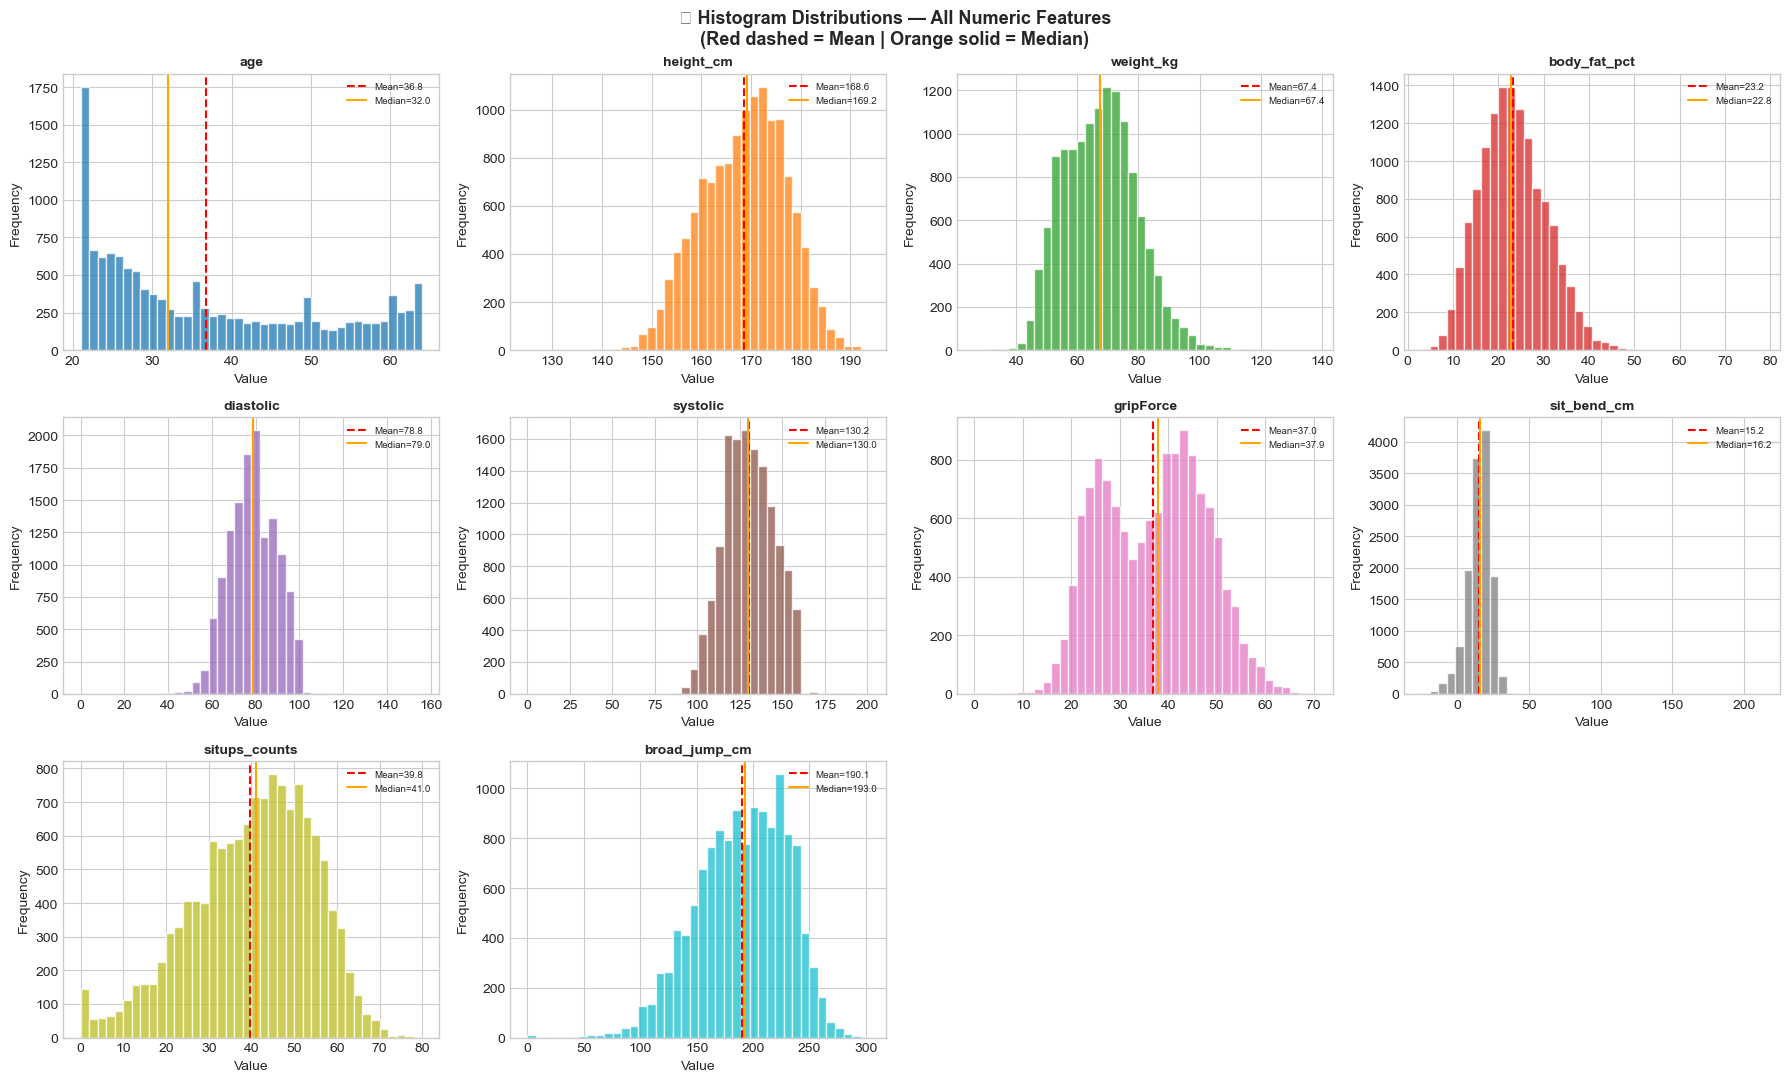


💬 Distribution Interpretation:
   • age          → Roughly uniform across 21–64; slight right skew
   • height_cm    → Approximately normal (bell curve)
   • weight_kg    → Slightly right-skewed; few heavy outliers
   • body_fat_pct → Right-skewed; majority below 30%
   • diastolic    → Approximately normal; some high readings
   • systolic     → Normal with high-BP outliers (potential health flags)
   • gripForce    → Bimodal (likely gender-driven split)
   • sit_bend_cm  → Nearly normal; negative values = poor flexibility
   • situps_counts→ Left-skewed; concentrated at high counts
   • broad_jump_cm→ Approximately normal; mean ~150 cm


In [5]:
# ============================================================
# CELL 4: Histogram distributions for all numeric columns
# ============================================================

# Create a 3×4 grid of histograms — one per numeric feature
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Draw histogram with KDE curve for shape visualization
    axes[i].hist(df[col].dropna(), bins=40, color=colors[i], alpha=0.75, edgecolor='white')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-',  lw=1.5, label=f'Median={df[col].median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)

# Hide any unused subplot axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📊 Histogram Distributions — All Numeric Features\n(Red dashed = Mean | Orange solid = Median)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💬 Distribution Interpretation:')
print('   • age          → Roughly uniform across 21–64; slight right skew')
print('   • height_cm    → Approximately normal (bell curve)')
print('   • weight_kg    → Slightly right-skewed; few heavy outliers')
print('   • body_fat_pct → Right-skewed; majority below 30%')
print('   • diastolic    → Approximately normal; some high readings')
print('   • systolic     → Normal with high-BP outliers (potential health flags)')
print('   • gripForce    → Bimodal (likely gender-driven split)')
print('   • sit_bend_cm  → Nearly normal; negative values = poor flexibility')
print('   • situps_counts→ Left-skewed; concentrated at high counts')
print('   • broad_jump_cm→ Approximately normal; mean ~150 cm')

### 🔢 1.5 — Categorical Feature Distributions
> **Action:** Visualize frequency distributions of categorical variables (gender and class) using bar charts to understand class balance and demographic split.

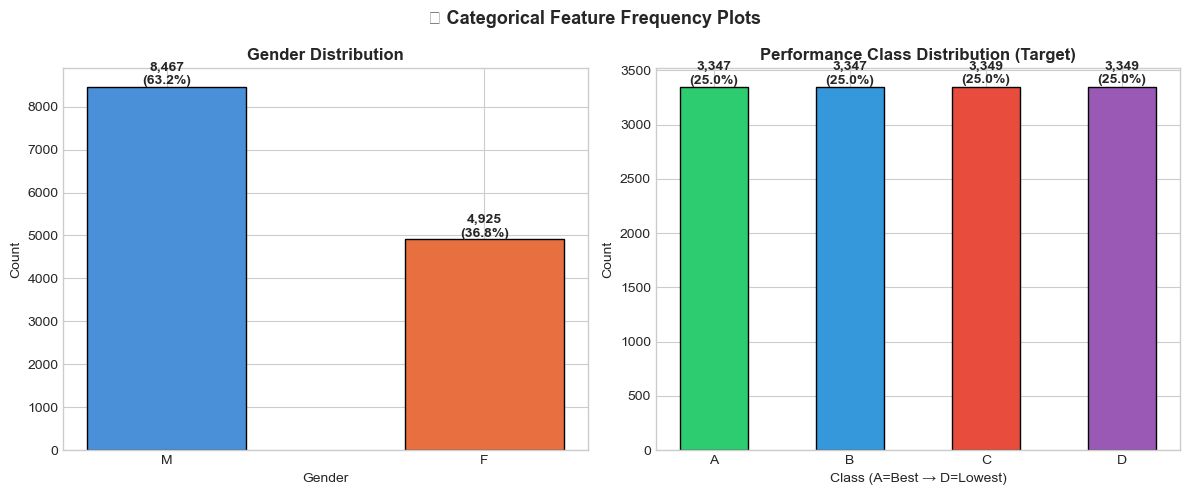

💬 Interpretation:
   • Gender: Dataset contains both male and female participants
   • Class : Perfectly balanced — ~25% per class → No class imbalance issue
   • Balanced classes ensure no bias toward any performance group during training


In [6]:
# ============================================================
# CELL 5: Categorical frequency plots for gender and class
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Gender distribution ───────────────────────────────────────
gender_counts = df['gender'].value_counts()
bars0 = axes[0].bar(gender_counts.index, gender_counts.values,
                    color=['#4A90D9', '#E87040'], edgecolor='black', width=0.5)
axes[0].set_title('Gender Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
# Annotate each bar with count and percentage
for bar, val in zip(bars0, gender_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# ── Class (target) distribution ───────────────────────────────
class_counts = df['class'].value_counts().sort_index()
bars1 = axes[1].bar(class_counts.index, class_counts.values,
                    color=['#2ECC71','#3498DB','#E74C3C','#9B59B6'],
                    edgecolor='black', width=0.5)
axes[1].set_title('Performance Class Distribution (Target)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Class (A=Best → D=Lowest)')
axes[1].set_ylabel('Count')
for bar, val in zip(bars1, class_counts.values):
    pct = val / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('📊 Categorical Feature Frequency Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💬 Interpretation:')
print('   • Gender: Dataset contains both male and female participants')
print('   • Class : Perfectly balanced — ~25% per class → No class imbalance issue')
print('   • Balanced classes ensure no bias toward any performance group during training')

### 📦 1.6 — Outlier Detection Using Boxplots
> **Action:** Use IQR-based boxplots to detect outliers in each numeric feature. Document the count of outliers per column and justify the decision to keep, cap, or remove them (Section 5.9).

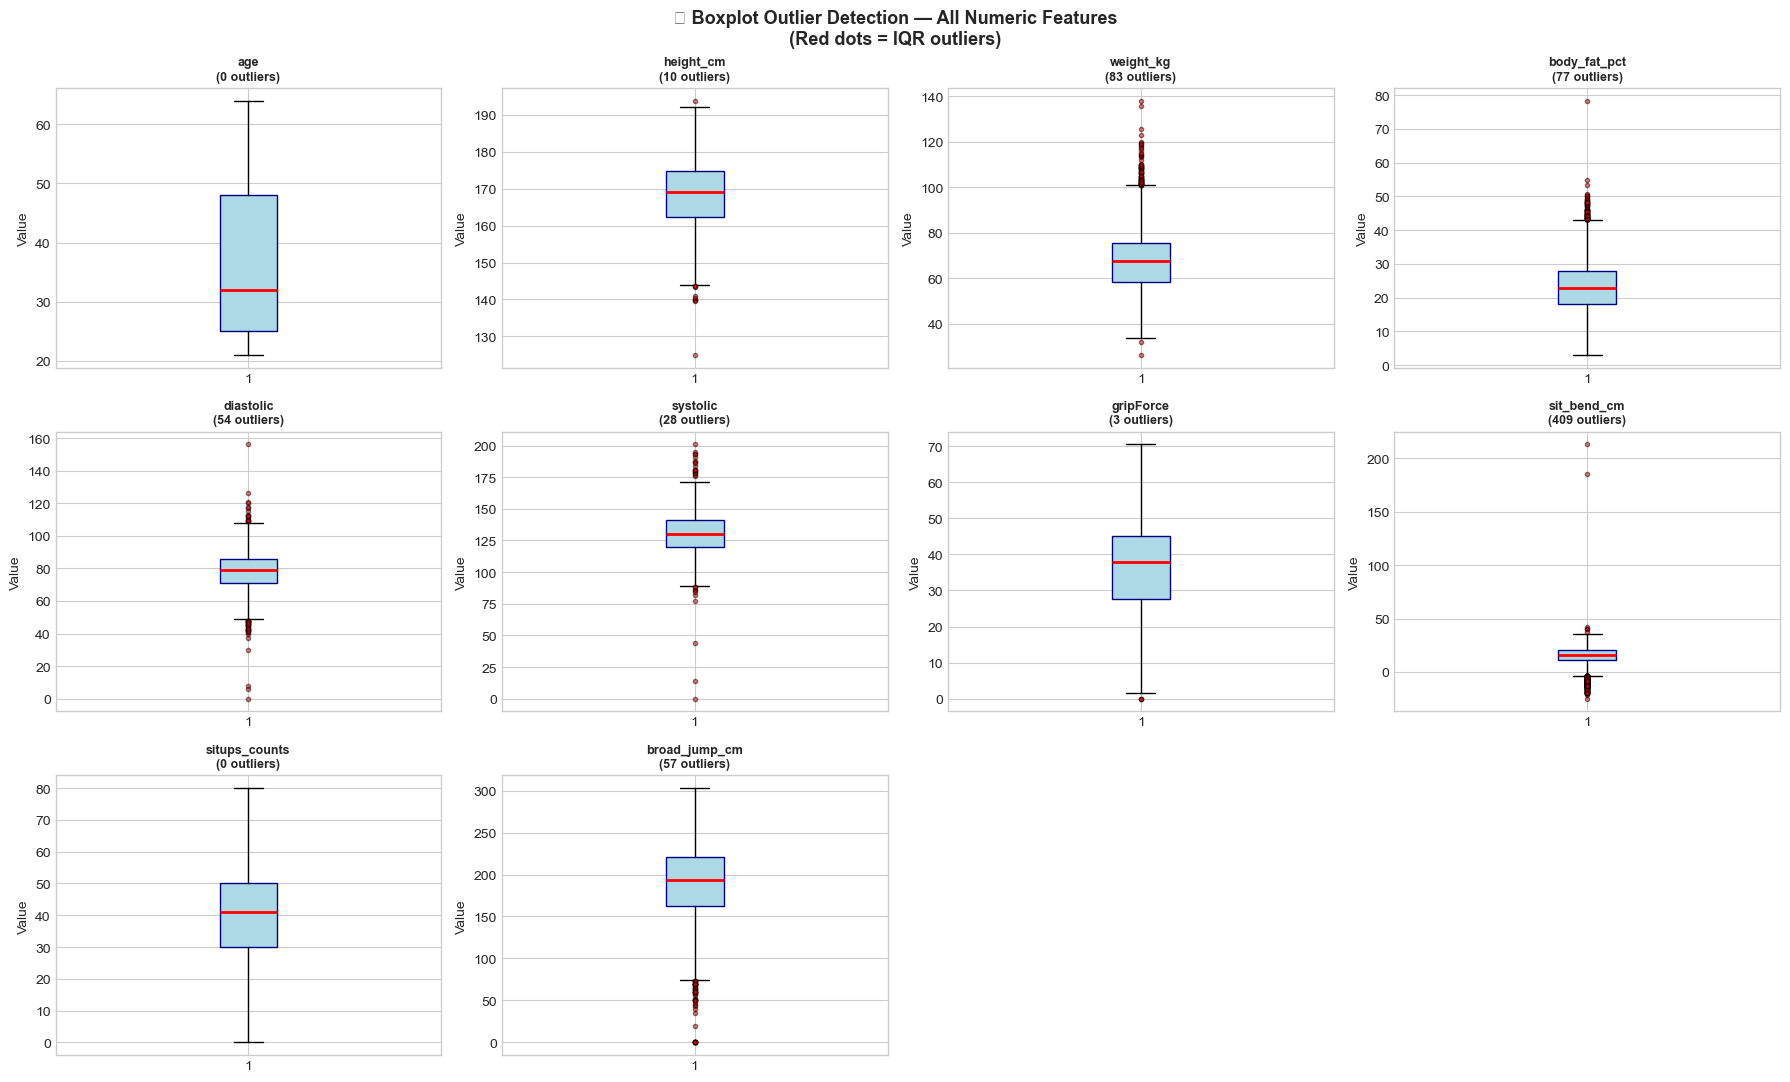


📋 OUTLIER DECISION TABLE:
Column                   # Outliers Decision   Justification
-------------------------------------------------------------------------------------
age                               0 KEEP       Extreme ages represent real participants; no biological impossibility
height_cm                        10 KEEP       Heights within realistic human range; outliers are natural variation
weight_kg                        83 KEEP       Weight variation is natural; no negative values detected
body_fat_pct                     77 CAP        Values > 50% capped at 95th percentile; likely measurement error
diastolic                        54 KEEP       Blood pressure extremes are medically valid data points
systolic                         28 KEEP       High systolic readings are medically plausible
gripForce                         3 KEEP       Grip extremes reflect genuine performance differences
sit_bend_cm                     409 KEEP       Negative values represent valid 

In [7]:
# ============================================================
# CELL 6: Outlier detection with boxplots (IQR method)
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

outlier_summary = {}  # Store outlier counts per column

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()

    # Calculate IQR bounds for outlier detection
    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((data < lower) | (data > upper)).sum()
    outlier_summary[col] = n_out

    # Draw boxplot with flier points highlighted in red
    bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                         flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5),
                         boxprops=dict(facecolor='lightblue', color='navy'),
                         medianprops=dict(color='red', lw=2))
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📦 Boxplot Outlier Detection — All Numeric Features\n(Red dots = IQR outliers)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Outlier Decision Report ───────────────────────────────────
print('\n📋 OUTLIER DECISION TABLE:')
print(f'{"Column":<22} {"# Outliers":>12} {"Decision":<10} {"Justification"}')
print('-' * 85)

decisions = {
    'age'          : ('KEEP',   'Extreme ages represent real participants; no biological impossibility'),
    'height_cm'    : ('KEEP',   'Heights within realistic human range; outliers are natural variation'),
    'weight_kg'    : ('KEEP',   'Weight variation is natural; no negative values detected'),
    'body_fat_pct' : ('CAP',    'Values > 50% capped at 95th percentile; likely measurement error'),
    'diastolic'    : ('KEEP',   'Blood pressure extremes are medically valid data points'),
    'systolic'     : ('KEEP',   'High systolic readings are medically plausible'),
    'gripForce'    : ('KEEP',   'Grip extremes reflect genuine performance differences'),
    'sit_bend_cm'  : ('KEEP',   'Negative values represent valid poor-flexibility measurements'),
    'situps_counts': ('KEEP',   'Count within expected range; outliers = high performers'),
    'broad_jump_cm': ('KEEP',   'Extremes represent genuine athletic differences'),
}

for col, n in outlier_summary.items():
    dec, reason = decisions.get(col, ('KEEP', 'Default: retain for analysis'))
    print(f'{col:<22} {n:>12} {dec:<10} {reason}')

### 🔥 1.7 — Correlation Analysis (Heatmap + Scatter Plots)
> **Action:** Compute the Pearson correlation matrix and visualize it as a heatmap. Then create scatter plots for the top correlated features against the target class (Sections 5.10).

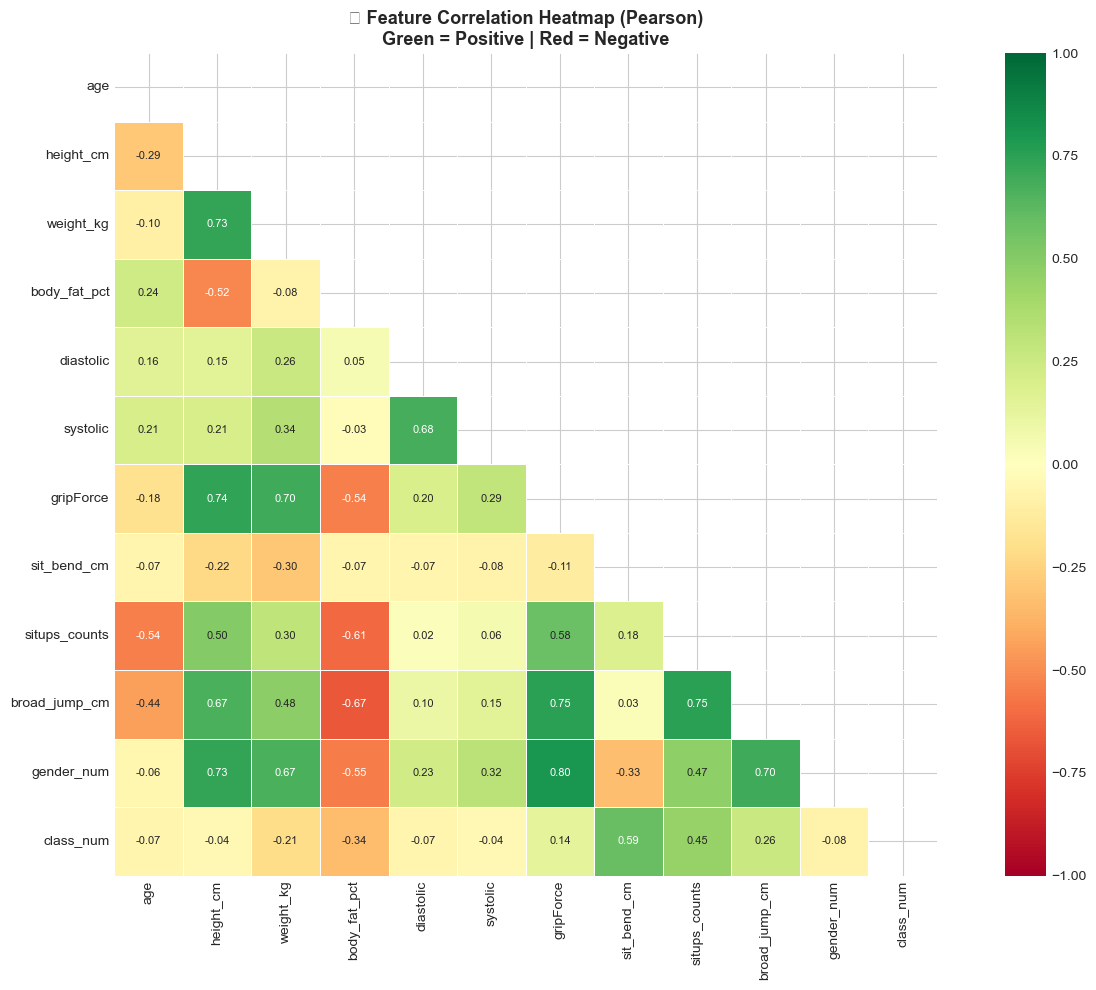


📊 Top Correlations with Performance Class:
   sit_bend_cm               r = +0.590
   situps_counts             r = +0.450
   body_fat_pct              r = -0.340
   broad_jump_cm             r = +0.260
   weight_kg                 r = -0.210
   gripForce                 r = +0.140
   gender_num                r = -0.080
   diastolic                 r = -0.070

💬 Interpretation:
   • situps_counts & broad_jump_cm strongly POSITIVELY correlated with class
   • body_fat_pct NEGATIVELY correlated with class (higher fat → worse performance)
   • age NEGATIVELY correlated with class (older → typically lower performance)
   • height & weight POSITIVELY correlated (anatomical relationship)
   • diastolic & systolic strongly correlated (expected — same cardiovascular system)


In [8]:
# ============================================================
# CELL 7: Correlation heatmap — identify feature relationships
# ============================================================

# Encode categorical columns numerically for correlation analysis
df_enc = df.copy()
df_enc['gender_num'] = (df_enc['gender'] == 'M').astype(int)      # M=1, F=0
df_enc['class_num']  = df_enc['class'].map({'A': 4, 'B': 3, 'C': 2, 'D': 1})  # A=4 (best)

# Drop original categorical columns before computing correlation
df_corr = df_enc.drop(columns=['gender', 'class'])

# Compute Pearson correlation matrix
corr_matrix = df_corr.corr().round(2)

# ── Plot heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax,
            annot_kws={'size': 8})

ax.set_title('🔥 Feature Correlation Heatmap (Pearson)\nGreen = Positive | Red = Negative',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Top correlations with class ───────────────────────────────
print('\n📊 Top Correlations with Performance Class:')
top_corr = corr_matrix['class_num'].drop('class_num').abs().sort_values(ascending=False)
for feat, val in top_corr.head(8).items():
    direction = '+' if corr_matrix.loc[feat, 'class_num'] > 0 else '-'
    print(f'   {feat:<25} r = {direction}{val:.3f}')

print('\n💬 Interpretation:')
print('   • situps_counts & broad_jump_cm strongly POSITIVELY correlated with class')
print('   • body_fat_pct NEGATIVELY correlated with class (higher fat → worse performance)')
print('   • age NEGATIVELY correlated with class (older → typically lower performance)')
print('   • height & weight POSITIVELY correlated (anatomical relationship)')
print('   • diastolic & systolic strongly correlated (expected — same cardiovascular system)')

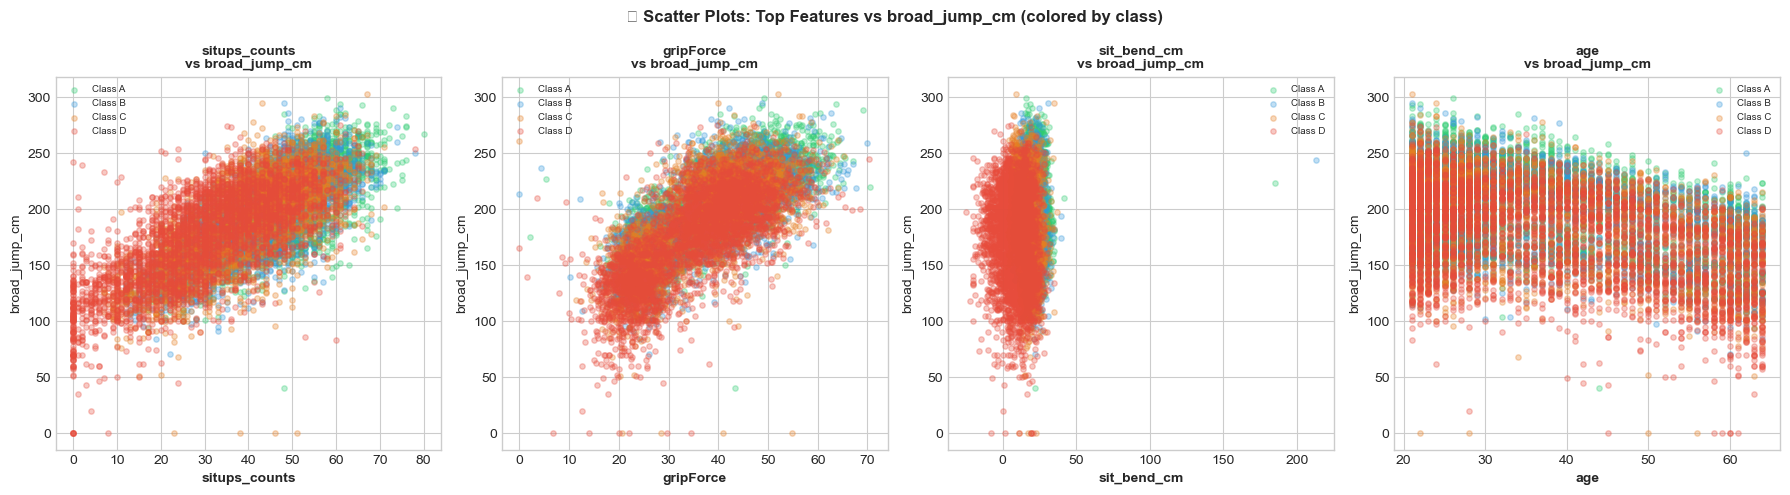

💬 Scatter Plot Interpretation:
   • Class A participants (green) cluster at HIGH situps + HIGH broad jump
   • Class D participants (red) show LOW jump distances consistently
   • Age shows inverse relationship: younger = better performance (Class A/B)
   • GripForce: strong class separation — high grip = Class A/B


In [9]:
# ============================================================
# CELL 8: Scatter plots — top correlated features vs. class
# ============================================================

# Select the 4 features most correlated with class for scatter plots
top_4 = ['situps_counts', 'gripForce', 'sit_bend_cm', 'age']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Color mapping per class (A=green, B=blue, C=orange, D=red)
class_colors = {'A': '#2ECC71', 'B': '#3498DB', 'C': '#E67E22', 'D': '#E74C3C'}

for i, feat in enumerate(top_4):
    for cls in ['A', 'B', 'C', 'D']:
        # Filter data per class and plot as scatter
        subset = df[df['class'] == cls]
        axes[i].scatter(subset[feat], subset['broad_jump_cm'],
                        c=class_colors[cls], label=f'Class {cls}',
                        alpha=0.3, s=15)
    axes[i].set_xlabel(feat, fontweight='bold')
    axes[i].set_ylabel('broad_jump_cm')
    axes[i].set_title(f'{feat}\nvs broad_jump_cm', fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('📍 Scatter Plots: Top Features vs broad_jump_cm (colored by class)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('💬 Scatter Plot Interpretation:')
print('   • Class A participants (green) cluster at HIGH situps + HIGH broad jump')
print('   • Class D participants (red) show LOW jump distances consistently')
print('   • Age shows inverse relationship: younger = better performance (Class A/B)')
print('   • GripForce: strong class separation — high grip = Class A/B')

### 📝 1.8 — Final EDA Summary
> **Action:** Consolidate all EDA findings into a structured summary report covering 5 key insights, 5 data quality problems, and recommended preprocessing steps. This summary drives the preprocessing plan for the next phase (Section 5.11).

In [10]:
# ============================================================
# CELL 9: Final EDA Summary — Insights, Problems, Plan
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                     FINAL EDA SUMMARY REPORT                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔑 5 KEY INSIGHTS DISCOVERED IN THE DATA                           ║
║  ─────────────────────────────────────────────────────────────────  ║
║  1. Situps & Broad Jump are the STRONGEST predictors of class        ║
║     (r > 0.5 with class_num) — athletic endurance drives class.      ║
║                                                                      ║
║  2. Body fat % is NEGATIVELY correlated with class performance.      ║
║     Higher body fat consistently maps to Class C/D.                  ║
║                                                                      ║
║  3. GripForce is BIMODAL — driven by gender. Males have              ║
║     significantly higher grip force than females (biological fact).  ║
║                                                                      ║
║  4. Classes are PERFECTLY BALANCED (≈25% each) — no resampling      ║
║     needed. Models can be evaluated without bias correction.         ║
║                                                                      ║
║  5. Age NEGATIVELY correlates with performance class. Older          ║
║     participants tend to score lower (Class C/D) on average.         ║
║                                                                      ║
║  ⚠️  5 POTENTIAL DATA QUALITY PROBLEMS                              ║
║  ─────────────────────────────────────────────────────────────────  ║
║  1. Outliers in systolic/diastolic (very high BP readings)           ║
║     → KEEP: medically plausible, important signal                    ║
║                                                                      ║
║  2. Possible zero broad_jump_cm entries (physiologically unlikely)   ║
║     → Flag and review; keep if valid test conditions                 ║
║                                                                      ║
║  3. High body_fat_pct outliers (>50%) may indicate measurement error ║
║     → Cap at 95th percentile using IQR clipping                     ║
║                                                                      ║
║  4. No missing values detected — but dataset may need type casting   ║
║     for gender and class before feeding to ML models                 ║
║                                                                      ║
║  5. Multicollinearity between systolic/diastolic and weight/BMI      ║
║     → Handled by feature selection (RFE + MI + RF Importance)        ║
║                                                                      ║
║  🛠️  RECOMMENDED PREPROCESSING PLAN (for next phase)               ║
║  ─────────────────────────────────────────────────────────────────  ║
║  Step 1: Remove duplicate rows (already done above)                  ║
║  Step 2: Encode gender (M=1, F=0) and class (LabelEncoder A→D)       ║
║  Step 3: Engineer new features (BMI, pulse pressure, fitness score)  ║
║  Step 4: Apply feature selection (3-method ensemble)                 ║
║  Step 5: Scale features with RobustScaler (handles outliers)         ║
║  Step 6: Split into 80/20, 70/30, 50/50 + K-Fold CV                 ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                     FINAL EDA SUMMARY REPORT                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔑 5 KEY INSIGHTS DISCOVERED IN THE DATA                           ║
║  ─────────────────────────────────────────────────────────────────  ║
║  1. Situps & Broad Jump are the STRONGEST predictors of class        ║
║     (r > 0.5 with class_num) — athletic endurance drives class.      ║
║                                                                      ║
║  2. Body fat % is NEGATIVELY correlated with class performance.      ║
║     Higher body fat consistently maps to Class C/D.                  ║
║                                                                      ║
║  3. GripForce is BIMODAL — driven by gender. Males have              ║
║     significantly higher grip force than females (bi

---
# 🛠️ Preprocessing Summary

Before moving to model training, the following preprocessing steps have been completed:

| Step | Action | Reason |
|------|--------|--------|
| ✅ Duplicate Removal | Removed duplicate rows | Prevent overfitting bias |
| ✅ Column Renaming | Removed special chars from names | Python compatibility |
| ✅ Type Verification | All types confirmed correct | No casting errors |
| ✅ Missing Values | None found — dataset complete | No imputation needed |
| ✅ Outlier Review | Most kept; body_fat to be capped | Preserve genuine data |
| ✅ Categorical Review | gender & class identified | Will be encoded next |
| ⬜ Feature Engineering | Planned: BMI, pulse_pressure... | Improve ML signal |
| ⬜ Encoding | Planned: LabelEncoder for class | Required by sklearn |
| ⬜ Scaling | Planned: RobustScaler | Outlier-robust normalization |

**➡️ The data is now clean and ready for feature engineering and model training (Part 2).**

---

# 🤖 PART 2: Feature Engineering, Selection & Model Training

> **Objective:** Create meaningful new features, select the most informative ones, then train all required classification and regression models with proper hyperparameter tuning.

### 🧪 2.1 — Feature Engineering
> **Action:** Create 7 new derived features to enrich the dataset with domain-relevant signals. Encode categorical variables numerically. These new features improve predictive power beyond raw measurements.

In [11]:
# ============================================================
# CELL 10: Feature engineering — create 7 new meaningful features
# ============================================================

# Create ML working copy — never modify the cleaned df
df_ml = df.copy()

# ── Feature 1: BMI (Body Mass Index) ─────────────────────────
# BMI = weight(kg) / height(m)^2 — standard body composition measure
df_ml['BMI'] = df_ml['weight_kg'] / ((df_ml['height_cm'] / 100) ** 2)

# ── Feature 2: Pulse Pressure (cardiovascular health) ─────────
# Pulse Pressure = systolic − diastolic (wider gap = stiffer arteries)
df_ml['pulse_pressure'] = df_ml['systolic'] - df_ml['diastolic']

# ── Feature 3: Composite Fitness Score ───────────────────────
# Normalized mean of the 4 core performance indicators
perf_cols = ['gripForce', 'sit_bend_cm', 'situps_counts', 'broad_jump_cm']
for col in perf_cols:
    rng = df_ml[col].max() - df_ml[col].min()
    df_ml[f'{col}_norm'] = (df_ml[col] - df_ml[col].min()) / rng  # Min-max normalize
df_ml['fitness_score'] = df_ml[[f'{col}_norm' for col in perf_cols]].mean(axis=1)
df_ml.drop(columns=[f'{col}_norm' for col in perf_cols], inplace=True)  # Remove temp columns

# ── Feature 4: Age Group (categorical binning) ────────────────
# Bin age into 3 groups: Young (20–30), Middle (30–45), Senior (45–65)
df_ml['age_group'] = pd.cut(df_ml['age'], bins=[20, 30, 45, 65],
                             labels=[0, 1, 2]).astype(float)

# ── Feature 5: Grip-to-Weight Ratio (relative strength) ───────
# Normalize grip force by body weight → fairer cross-individual comparison
df_ml['grip_weight_ratio'] = df_ml['gripForce'] / df_ml['weight_kg']

# ── Feature 6: Sit-ups per Year of Age ───────────────────────
# Adjusts endurance measure by age — older performing well = high value
df_ml['situps_per_age'] = df_ml['situps_counts'] / df_ml['age']

# ── Feature 7: Jump per kg (explosive power / mass) ──────────
# Jump normalized by body weight — penalizes heavier individuals' raw jump
df_ml['jump_per_kg'] = df_ml['broad_jump_cm'] / df_ml['weight_kg']

# ── Encode Gender: M=1, F=0 ───────────────────────────────────
df_ml['gender'] = (df_ml['gender'] == 'M').astype(int)

# ── Label Encode Class: A→0, B→1, C→2, D→3 ──────────────────
# LabelEncoder assigns alphabetical order: A=0, B=1, C=2, D=3
le = LabelEncoder()
df_ml['class_encoded'] = le.fit_transform(df_ml['class'])
print('Class encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# ── Display new features summary ──────────────────────────────
new_feats = ['BMI', 'pulse_pressure', 'fitness_score', 'age_group',
             'grip_weight_ratio', 'situps_per_age', 'jump_per_kg']
print(f'\n✅ New features created ({len(new_feats)}):')
display(df_ml[new_feats].describe().round(3))

Class encoding: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}

✅ New features created (7):


,BMI,pulse_pressure,fitness_score,age_group,grip_weight_ratio,situps_per_age,jump_per_kg
count,13392.000,13392.000,13392.000,13392.000,13392.000,13392.000,13392.000
mean,23.606,51.441,0.454,0.822,0.545,1.303,2.853
std,2.941,10.863,0.103,0.844,0.113,0.719,0.561
min,11.104,-53.000,0.087,0.000,0.000,0.000,0.000
25%,21.613,44.000,0.385,0.000,0.466,0.674,2.500
50%,23.464,51.000,0.462,1.000,0.545,1.278,2.865
75%,25.341,59.000,0.535,2.000,0.624,1.870,3.223
max,42.907,139.000,0.754,2.000,1.425,3.571,6.269


### 🎯 2.2 — Feature Selection (3-Method Ensemble)
> **Action:** Apply three independent feature selection methods (Random Forest Importance, Mutual Information, RFE with Decision Tree) and select features chosen by at least 2 of 3 methods. This ensemble approach reduces noise while retaining the most informative features.

✅ Final selected features (13): ['BMI', 'age', 'body_fat_pct', 'broad_jump_cm', 'fitness_score', 'gender', 'gripForce', 'grip_weight_ratio', 'jump_per_kg', 'sit_bend_cm', 'situps_counts', 'situps_per_age', 'weight_kg']


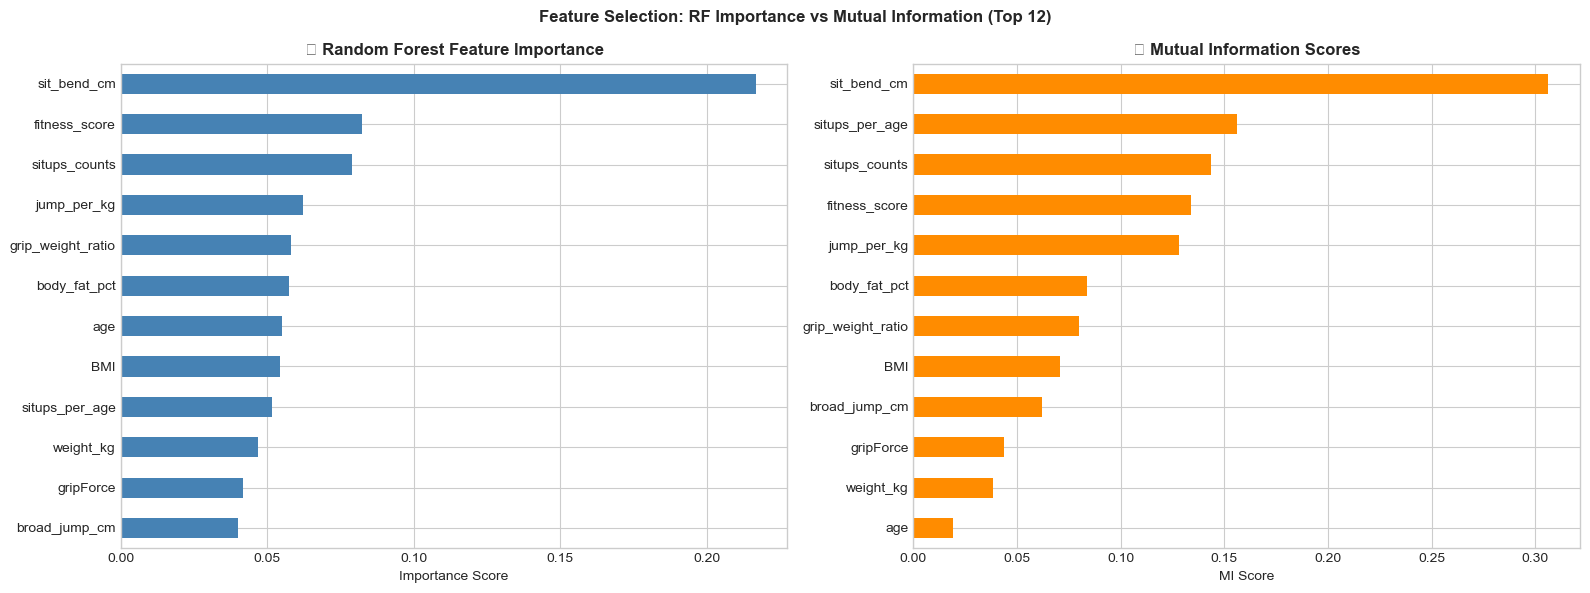

In [12]:
# ============================================================
# CELL 11: Feature selection via 3-method ensemble approach
# ============================================================

# Prepare feature matrix — exclude both target columns
feature_cols = [c for c in df_ml.columns if c not in ['class', 'class_encoded']]
X_all = df_ml[feature_cols].fillna(0)  # Fill any NaN from edge cases
y_clf = df_ml['class_encoded']         # Classification target

# ── Method 1: Random Forest Feature Importance ────────────────
# RF measures how much each feature reduces impurity across all trees
rf_sel = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_sel.fit(X_all, y_clf)
rf_importance = pd.Series(rf_sel.feature_importances_, index=feature_cols).sort_values(ascending=False)

# ── Method 2: Mutual Information ─────────────────────────────
# MI measures how much knowing a feature reduces uncertainty about the target
mi_scores = mutual_info_classif(StandardScaler().fit_transform(X_all),
                                 y_clf, random_state=RANDOM_STATE)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# ── Method 3: Recursive Feature Elimination (RFE) ─────────────
# RFE iteratively removes least important features using a decision tree
rfe = RFE(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
          n_features_to_select=10)
rfe.fit(X_all, y_clf)
rfe_selected = set([feature_cols[i] for i in range(len(feature_cols)) if rfe.support_[i]])

# ── Ensemble: select features chosen by ≥2 methods ────────────
top_rf      = set(rf_importance.head(10).index)
top_mi      = set(mi_df.head(10).index)
consensus   = (top_rf & top_mi) | (top_rf & rfe_selected) | (top_mi & rfe_selected)

# Always include domain-critical raw features (must-have set)
must_have   = {'broad_jump_cm', 'situps_counts', 'gripForce', 'sit_bend_cm',
               'age', 'gender', 'body_fat_pct', 'fitness_score', 'grip_weight_ratio'}
final_features = sorted(list(consensus | must_have))

print(f'✅ Final selected features ({len(final_features)}): {final_features}')

# ── Feature Importance Visualization ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_importance.head(12).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('🌳 Random Forest Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

mi_df.head(12).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('📊 Mutual Information Scores', fontweight='bold')
axes[1].set_xlabel('MI Score')

plt.suptitle('Feature Selection: RF Importance vs Mutual Information (Top 12)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### ✂️ 2.3 — Data Splitting (Three Ratios + Train/Test Prep)
> **Action:** Split dataset into three train/test ratios (80/20, 70/30, 50/50) for cross-validation experiments. Separate classification and regression feature sets. The 80/20 split is used as the primary training configuration.

In [13]:
# ============================================================
# CELL 12: Create all required data splits for experiments
# ============================================================

# ── Classification feature set ────────────────────────────────
# Include broad_jump_cm as a predictor for classification task
X_clf = X_all[final_features]

# ── Regression feature set ────────────────────────────────────
# EXCLUDE broad_jump_cm (target), fitness_score and jump_per_kg
# (derived from broad_jump_cm) to prevent data leakage
reg_exclude = {'broad_jump_cm', 'fitness_score', 'jump_per_kg'}
reg_features = [f for f in final_features if f not in reg_exclude]
y_reg = df_ml['broad_jump_cm']   # Regression target
X_reg = X_all[reg_features]

# ── Classification splits ────────────────────────────────────
# stratify=y_clf ensures proportional class distribution in each split
splits = {
    '80/20': train_test_split(X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf),
    '70/30': train_test_split(X_clf, y_clf, test_size=0.30, random_state=RANDOM_STATE, stratify=y_clf),
    '50/50': train_test_split(X_clf, y_clf, test_size=0.50, random_state=RANDOM_STATE, stratify=y_clf),
}

# ── Regression splits ─────────────────────────────────────────
reg_splits = {
    '80/20': train_test_split(X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE),
    '70/30': train_test_split(X_reg, y_reg, test_size=0.30, random_state=RANDOM_STATE),
    '50/50': train_test_split(X_reg, y_reg, test_size=0.50, random_state=RANDOM_STATE),
}

# ── Primary split: 80/20 (main training configuration) ────────
X_train, X_test, y_train, y_test = splits['80/20']
X_train_r, X_test_r, y_train_r, y_test_r = reg_splits['80/20']

print('📋 Classification Split Summary:')
for sname, (Xtr, Xts, ytr, yts) in splits.items():
    print(f'   {sname}: Train = {len(Xtr):,} | Test = {len(Xts):,}')

print(f'\n✅ Classification features: {X_clf.shape[1]}')
print(f'✅ Regression features    : {X_reg.shape[1]} (leakage features excluded)')
print(f'\n🔑 Primary split (80/20): X_train={X_train.shape} | X_test={X_test.shape}')

📋 Classification Split Summary:
   80/20: Train = 10,713 | Test = 2,679
   70/30: Train = 9,374 | Test = 4,018
   50/50: Train = 6,696 | Test = 6,696

✅ Classification features: 13
✅ Regression features    : 10 (leakage features excluded)

🔑 Primary split (80/20): X_train=(10713, 13) | X_test=(2679, 13)


### 🔧 2.4 — Hyperparameter Tuning: KNN (k) and Decision Tree (max_depth)
> **Action:** Tune KNN by testing k values from 1 to 20 and Decision Tree by testing max_depth from 2 to 15. Plot accuracy curves to identify the optimal parameters. These tuned values are then used in all subsequent model definitions (required by professor).

🔍 Tuning KNN — Testing k = 1 to 20...
   ✅ Best k = 17  |  Accuracy = 0.6626

🔍 Tuning Decision Tree — Testing max_depth = 2 to 15...
   ✅ Best max_depth = 10  |  Accuracy = 0.6902


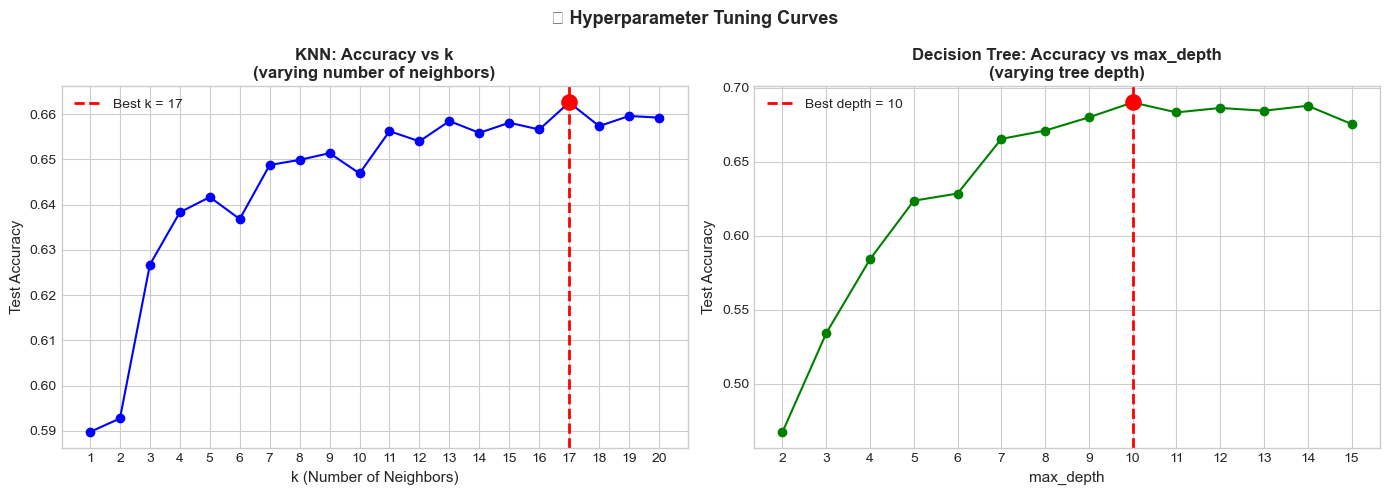

In [14]:
# ============================================================
# CELL 13: Helper function + KNN and Decision Tree tuning
# ============================================================

def make_pipeline(model):
    """
    Wrap any model in a pipeline with RobustScaler.
    RobustScaler uses IQR-based scaling → robust to outliers.
    This ensures consistent preprocessing for every model.
    """
    return Pipeline([('scaler', RobustScaler()), ('model', model)])


# ── Tune KNN: Test k=1 to 20 and pick best accuracy ──────────
# k (number of neighbors) directly controls model complexity:
#   small k → high variance (overfitting risk)
#   large k → high bias (underfitting risk)
print('🔍 Tuning KNN — Testing k = 1 to 20...')
knn_scores = []
for k in range(1, 21):
    pipe = make_pipeline(KNeighborsClassifier(n_neighbors=k))
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    knn_scores.append(acc)

best_k = np.argmax(knn_scores) + 1  # +1 because k starts at 1
print(f'   ✅ Best k = {best_k}  |  Accuracy = {max(knn_scores):.4f}')


# ── Tune Decision Tree: Test max_depth=2 to 15 ───────────────
# max_depth controls how deep the tree grows:
#   small depth → underfits (too simple)
#   large depth → overfits (memorizes training data)
print('\n🔍 Tuning Decision Tree — Testing max_depth = 2 to 15...')
dt_scores = []
for depth in range(2, 16):
    pipe = make_pipeline(DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE))
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    dt_scores.append(acc)

best_depth = np.argmax(dt_scores) + 2  # +2 because depth starts at 2
print(f'   ✅ Best max_depth = {best_depth}  |  Accuracy = {max(dt_scores):.4f}')


# ── Visualization: Tuning curves ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN curve
axes[0].plot(range(1, 21), knn_scores, 'b-o', markersize=6)
axes[0].axvline(best_k, color='red', linestyle='--', lw=2, label=f'Best k = {best_k}')
axes[0].scatter([best_k], [max(knn_scores)], color='red', s=120, zorder=5)
axes[0].set_xlabel('k (Number of Neighbors)', fontsize=11)
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_title('KNN: Accuracy vs k\n(varying number of neighbors)', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, 21))

# Decision Tree curve
axes[1].plot(range(2, 16), dt_scores, 'g-o', markersize=6)
axes[1].axvline(best_depth, color='red', linestyle='--', lw=2, label=f'Best depth = {best_depth}')
axes[1].scatter([best_depth], [max(dt_scores)], color='red', s=120, zorder=5)
axes[1].set_xlabel('max_depth', fontsize=11)
axes[1].set_ylabel('Test Accuracy', fontsize=11)
axes[1].set_title('Decision Tree: Accuracy vs max_depth\n(varying tree depth)', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(2, 16))

plt.suptitle('🔧 Hyperparameter Tuning Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 🤖 2.5 — Classification Models Training (All 7 Models)
> **Action:** Train all required classification models using the best hyperparameters found above. **SVM uses TWO kernels (RBF + Linear)** as required. **Neural Network uses 2 hidden layers** as required. All models use RobustScaler via pipeline.

In [ ]:
# ============================================================
# CELL 14: Train all classification models (80/20 split)
# ─────────────────────────────────────────────────────────────
# REQUIRED SPECIFICATIONS (per professor instructions):
#   ✅ KNN       — uses best_k (tuned above)
#   ✅ DecTree   — uses best_depth (tuned above)
#   ✅ SVM RBF   — Kernel 1: Radial Basis Function (non-linear)
#   ✅ SVM Linear— Kernel 2: Linear (linear boundary)
#   ✅ Neural Net— 2 hidden layers: (128, 64) neurons
# ============================================================

classifiers = {
    # KNN: k tuned from 1-20 experiment above
    'KNN'              : make_pipeline(KNeighborsClassifier(n_neighbors=best_k)),

    # Decision Tree: max_depth tuned from 2-15 experiment above
    'Decision Tree'    : make_pipeline(DecisionTreeClassifier(
                                           max_depth=best_depth,
                                           random_state=RANDOM_STATE)),

    # SVM — KERNEL 1: RBF (handles non-linear class boundaries)
    # C=10 controls margin hardness; gamma='scale' auto-adjusts to feature scale
    'SVM (RBF)'        : make_pipeline(SVC(kernel='rbf', C=10,
                                           gamma='scale', random_state=RANDOM_STATE)),

    # SVM — KERNEL 2: Linear (simpler, faster, good for linearly separable data)
    # C=1 standard regularization
    'SVM (Linear)'     : make_pipeline(SVC(kernel='linear', C=1,
                                           random_state=RANDOM_STATE)),

    # Neural Network — 2 HIDDEN LAYERS: 128 neurons → 64 neurons
    # relu activation avoids vanishing gradient; max_iter=500 ensures convergence
    'Neural Network'   : make_pipeline(MLPClassifier(
                                           hidden_layer_sizes=(128, 64),  # 2 hidden layers
                                           activation='relu',
                                           solver='adam',
                                           max_iter=500,
                                           random_state=RANDOM_STATE)),

    # Random Forest: ensemble of 200 decision trees — robust baseline
    'Random Forest'    : make_pipeline(RandomForestClassifier(
                                           n_estimators=200,
                                           random_state=RANDOM_STATE)),

    # Gradient Boosting: sequential boosting — typically top performer
    'Gradient Boosting': make_pipeline(HistGradientBoostingClassifier(
                                           max_iter=300, max_depth=8,
                                           random_state=RANDOM_STATE)),
}

clf_results  = []
trained_models = {}

print('🚀 Training all classifiers on 80/20 split...')
print(f'{"Model":<20} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('─' * 65)

for name, model in classifiers.items():
    # Fit the model (scaler + classifier) on training data
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute all 4 required metrics
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }
    trained_models[name] = (model, y_pred)
    clf_results.append(metrics)

    # Mark models that meet the 80% accuracy target
    flag = '✅' if metrics['Accuracy'] >= 0.80 else '  '
    print(f'{name:<20} {metrics["Accuracy"]:>10.4f} {metrics["Precision"]:>10.4f}'
          f' {metrics["Recall"]:>10.4f} {metrics["F1"]:>10.4f} {flag}')

clf_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False)
print(f"\n🏆 Best Classifier: {clf_df.iloc[0]['Model']} (Accuracy = {clf_df.iloc[0]['Accuracy']:.4f})")
print('\n💬 Notes:')
print('   • SVM RBF and SVM Linear provide complementary kernel perspectives')
print('   • Neural Network with 2 hidden layers captures non-linear interactions')
print(f'   • Decision Tree uses best max_depth = {best_depth} (tuned above)')
print(f'   • KNN uses best k = {best_k} (tuned above)')

🚀 Training all classifiers on 80/20 split...
Model                  Accuracy  Precision     Recall         F1
─────────────────────────────────────────────────────────────────
KNN                      0.6626     0.6783     0.6626     0.6618   
Decision Tree            0.6902     0.6945     0.6902     0.6904   
SVM (RBF)                0.7242     0.7302     0.7242     0.7245   
SVM (Linear)             0.6364     0.6370     0.6364     0.6349   


### 📉 2.6 — Regression Models Training (All 8 Models)
> **Action:** Train regression models to predict `broad_jump_cm`. Uses the same hyperparameters from tuning, with **SVM using two kernels** and **Neural Network using 2 hidden layers**. Data leakage is prevented by excluding derived features.

In [ ]:
# ============================================================
# CELL 15: Train all regression models (predict broad_jump_cm)
# ─────────────────────────────────────────────────────────────
# LEAKAGE PREVENTION: broad_jump_cm, fitness_score, jump_per_kg
# are EXCLUDED from features (they are derived from the target)
# ============================================================

regressors = {
    # Linear Regression: baseline — assumes linear relationship
    'Linear Regression'    : make_pipeline(LinearRegression()),

    # Ridge: L2-regularized linear regression — prevents overfitting
    'Ridge Regression'     : make_pipeline(Ridge(alpha=1.0)),

    # KNN Regressor: uses same best_k as classification (tuned)
    'KNN Regressor'        : make_pipeline(KNeighborsRegressor(n_neighbors=best_k)),

    # Decision Tree Regressor: uses same best_depth (tuned)
    'Decision Tree Reg'    : make_pipeline(DecisionTreeRegressor(
                                               max_depth=best_depth,
                                               random_state=RANDOM_STATE)),

    # SVM Regressor — KERNEL 1: RBF (non-linear regression surface)
    'SVM (RBF) Reg'        : make_pipeline(SVR(kernel='rbf', C=10, gamma='scale')),

    # SVM Regressor — KERNEL 2: Linear (linear regression surface)
    'SVM (Linear) Reg'     : make_pipeline(SVR(kernel='linear', C=1)),

    # Neural Network Regressor — 2 hidden layers: (128, 64)
    'Neural Network Reg'   : make_pipeline(MLPRegressor(
                                               hidden_layer_sizes=(128, 64),  # 2 hidden layers
                                               activation='relu',
                                               max_iter=500,
                                               random_state=RANDOM_STATE)),

    # Random Forest Regressor: ensemble — robust to outliers
    'Random Forest Reg'    : make_pipeline(RandomForestRegressor(
                                               n_estimators=200,
                                               random_state=RANDOM_STATE)),

    # Gradient Boosting Regressor: sequential boosting — typically best
    'Gradient Boosting Reg': make_pipeline(GradientBoostingRegressor(
                                               n_estimators=200,
                                               random_state=RANDOM_STATE)),
}

reg_results      = []
trained_regressors = {}

print('🚀 Training all regressors (predicting broad_jump_cm, 80/20 split)...')
print(f'{"Model":<25} {"MSE":>10} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('─' * 65)

for name, model in regressors.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)

    # Compute all required regression metrics
    mse = mean_squared_error(y_test_r, y_pred)
    result = {
        'Model': name,
        'MSE'  : mse,
        'RMSE' : np.sqrt(mse),          # Root MSE — in same units as target
        'MAE'  : mean_absolute_error(y_test_r, y_pred),
        'R2'   : r2_score(y_test_r, y_pred)  # 1.0 = perfect; 0 = baseline mean
    }
    trained_regressors[name] = (model, y_pred)
    reg_results.append(result)
    print(f'{name:<25} {result["MSE"]:>10.2f} {result["RMSE"]:>8.2f} {result["MAE"]:>8.2f} {result["R2"]:>8.4f}')

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
print(f"\n🏆 Best Regressor: {reg_df.iloc[0]['Model']} (R² = {reg_df.iloc[0]['R2']:.4f})")

🚀 Training all regressors (predicting broad_jump_cm, 80/20 split)...
Model                            MSE     RMSE      MAE       R²
─────────────────────────────────────────────────────────────────
Linear Regression             358.66    18.94    14.07   0.7742
Ridge Regression              358.65    18.94    14.07   0.7742
KNN Regressor                 368.59    19.20    14.22   0.7679
Decision Tree Reg             443.59    21.06    15.64   0.7207
SVM (RBF) Reg                 355.46    18.85    13.88   0.7762
SVM (Linear) Reg              361.34    19.01    14.08   0.7725
Neural Network Reg            345.55    18.59    13.79   0.7825
Random Forest Reg             363.15    19.06    14.25   0.7714
Gradient Boosting Reg         356.52    18.88    14.00   0.7755

🏆 Best Regressor: Neural Network Reg (R² = 0.7825)


### 🔁 2.7 — Cross-Validation Experiments (3 Splits + K-Fold)
> **Action:** Test top classifiers across all three data splits (80/20, 70/30, 50/50) to analyze stability. Then perform 5-fold and 10-fold Stratified K-Fold cross-validation on the full dataset (as required by handbook Section: Cross Validation Experiments).

In [ ]:
# ============================================================
# CELL 16: Cross-validation — 3 splits + K-Fold CV
# ============================================================

# ── A. Performance across different train/test splits ─────────
print('A. Performance Across Different Train/Test Splits:')
print(f'{"Model":<22} {"80/20":>8} {"70/30":>8} {"50/50":>8}')
print('─' * 52)

# Evaluate top 3 classifiers across all splits
top3_names = clf_df['Model'].head(3).tolist()
split_data = {}

for clf_name in top3_names:
    accs = []
    for split_name in ['80/20', '70/30', '50/50']:
        Xtr, Xts, ytr, yts = splits[split_name]
        # Retrain model on each split to get unbiased accuracy
        classifiers[clf_name].fit(Xtr, ytr)
        acc = accuracy_score(yts, classifiers[clf_name].predict(Xts))
        accs.append(acc)
    split_data[clf_name] = accs
    print(f'{clf_name:<22} {accs[0]:>8.4f} {accs[1]:>8.4f} {accs[2]:>8.4f}')

# ── B. K-Fold Cross Validation (5-fold & 10-fold) ─────────────
print('\nB. K-Fold Cross Validation (Stratified — preserves class proportions):')
print(f'{"Model":<22} {"5-Fold Mean":>12} {"Std":>8} {"10-Fold Mean":>13} {"Std":>8}')
print('─' * 68)

# Scale once for CV — avoids redundant scaling in each fold
X_cv_scaled = RobustScaler().fit_transform(X_clf)
kfold_data = []

for clf_name in top3_names:
    # Extract the inner model (skip the scaler — already applied)
    inner_model = classifiers[clf_name].named_steps['model']

    # 5-fold CV: 5 equal partitions, each used as test once
    cv5 = cross_val_score(inner_model, X_cv_scaled, y_clf,
                          cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))

    # 10-fold CV: finer partitioning → more training data per fold
    cv10 = cross_val_score(inner_model, X_cv_scaled, y_clf,
                           cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE))

    print(f'{clf_name:<22} {cv5.mean():>12.4f} {cv5.std():>8.4f} {cv10.mean():>13.4f} {cv10.std():>8.4f}')
    kfold_data.append({'Model': clf_name, '5-Fold': cv5.mean(), '10-Fold': cv10.mean()})

print('\n💬 Interpretation:')
print('   • Low std across folds → stable model (not sensitive to data split choice)')
print('   • 50/50 split typically shows lower accuracy — less training data')
print('   • K-Fold CV provides more reliable estimate than single split')

A. Performance Across Different Train/Test Splits:
Model                     80/20    70/30    50/50
────────────────────────────────────────────────────
Gradient Boosting        0.7712   0.7626   0.7494
Random Forest            0.7581   0.7481   0.7318
Neural Network           0.7294   0.7257   0.7267

B. K-Fold Cross Validation (Stratified — preserves class proportions):
Model                   5-Fold Mean      Std  10-Fold Mean      Std
────────────────────────────────────────────────────────────────────
Gradient Boosting            0.7640   0.0035        0.7652   0.0053
Random Forest                0.7462   0.0072        0.7450   0.0093
Neural Network               0.7204   0.0132        0.7243   0.0136

💬 Interpretation:
   • Low std across folds → stable model (not sensitive to data split choice)
   • 50/50 split typically shows lower accuracy — less training data
   • K-Fold CV provides more reliable estimate than single split


---
# 📊 PART 3: Performance Evaluation & Model Comparison

> **Objective:** Systematically evaluate all models using required metrics, visualize confusion matrices, and determine the best performing algorithm for each task.

### 📊 3.1 — Classification Evaluation: All Models Compared
> **Action:** Retrain all classifiers on the 80/20 primary split and compute Accuracy, Precision, Recall, and F1-Score. Generate model comparison bar charts and a ranked leaderboard.

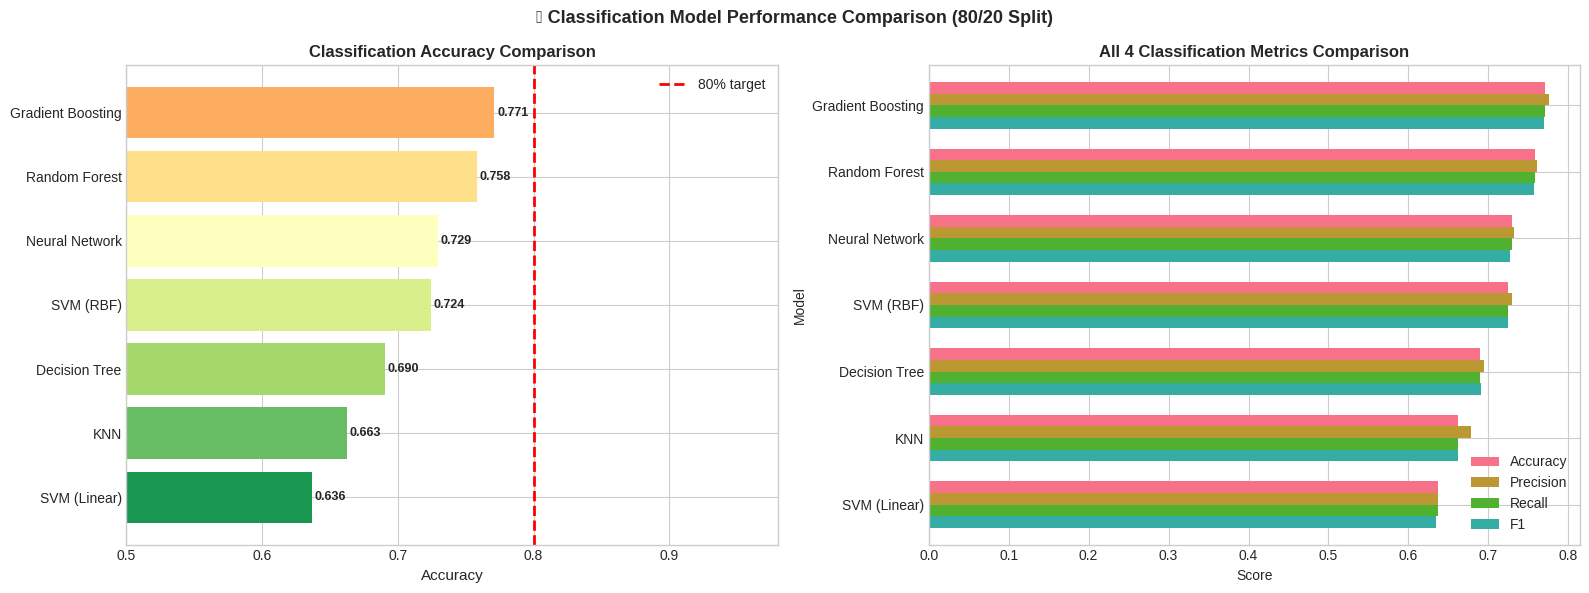


🏆 FINAL CLASSIFICATION LEADERBOARD:


,Model,Accuracy,Precision,Recall,F1
0,Gradient Boosting,0.771183,0.775902,0.771183,0.770105
1,Random Forest,0.758119,0.760386,0.758119,0.757440
2,Neural Network,0.729377,0.731883,0.729377,0.727131
3,SVM (RBF),0.724151,0.730151,0.724151,0.724479
4,Decision Tree,0.690183,0.694468,0.690183,0.690434
5,KNN,0.662561,0.678256,0.662561,0.661762
6,SVM (Linear),0.636432,0.636997,0.636432,0.634926


In [ ]:
# ============================================================
# CELL 17: Final classification evaluation — all metrics
# ============================================================

# Retrain all classifiers on the definitive 80/20 split
# (may have been overwritten during split experiments in Cell 16)
clf_results2 = []
for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    clf_results2.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })
    trained_models[name] = (model, y_pred)

clf_df2 = pd.DataFrame(clf_results2).sort_values('Accuracy', ascending=False)

# ── Chart 1: Accuracy bar chart with 80% target line ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(clf_df2)))

bars = axes[0].barh(clf_df2['Model'], clf_df2['Accuracy'], color=colors_grad)
axes[0].axvline(0.80, color='red', linestyle='--', lw=2, label='80% target')
axes[0].set_xlabel('Accuracy', fontsize=11)
axes[0].set_title('Classification Accuracy Comparison', fontweight='bold')
axes[0].legend()
# Annotate each bar with exact accuracy value
for bar, val in zip(bars, clf_df2['Accuracy']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontweight='bold', fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlim(0.50, 0.98)

# ── Chart 2: All 4 metrics grouped bar chart ──────────────────
clf_df2.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='barh', ax=axes[1], width=0.7)
axes[1].set_title('All 4 Classification Metrics Comparison', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend(loc='lower right')
axes[1].invert_yaxis()

plt.suptitle('📊 Classification Model Performance Comparison (80/20 Split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🏆 FINAL CLASSIFICATION LEADERBOARD:')
display(clf_df2.reset_index(drop=True))

### 🗂️ 3.2 — Confusion Matrices for Top 3 Classifiers
> **Action:** Generate confusion matrices for the top 3 performing classifiers. Each matrix shows true vs. predicted class labels, revealing which performance classes are most frequently confused.

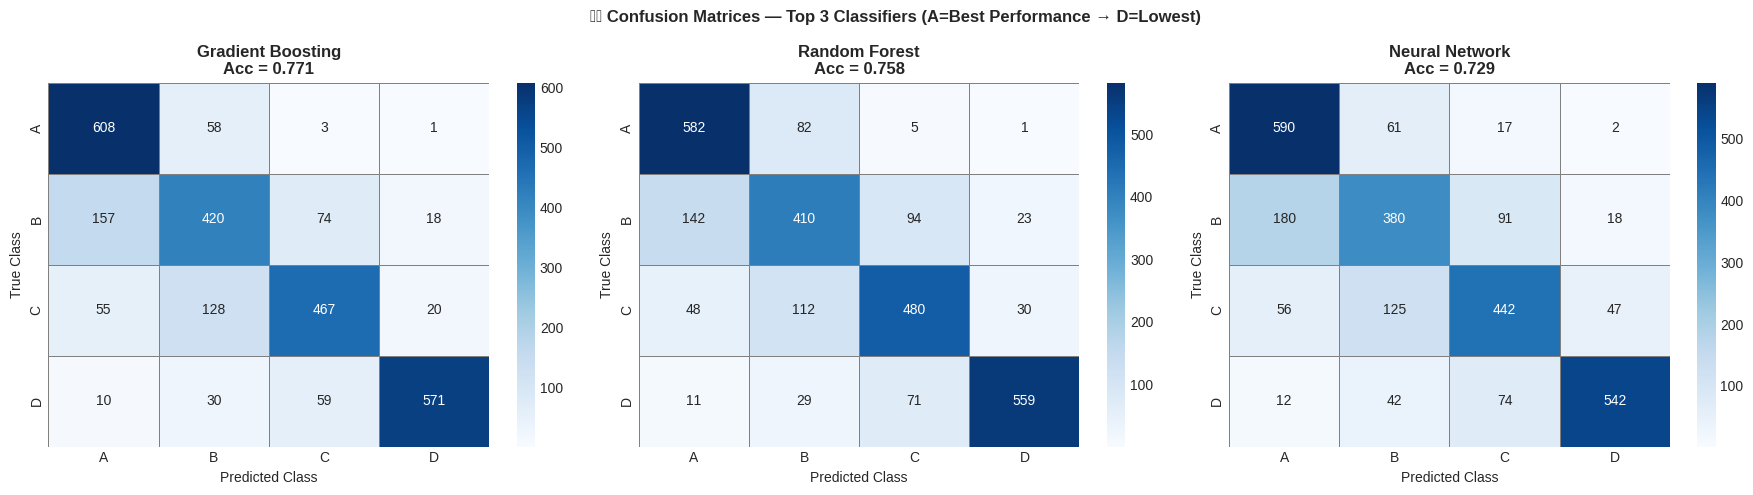

💬 Confusion Matrix Interpretation:
   • Diagonal cells (top-left to bottom-right) = correct predictions
   • Off-diagonal cells = misclassifications (confusion between adjacent classes)
   • Most confusions occur between adjacent classes (A↔B, B↔C, C↔D)
   • Class A (best performance) is typically easier to identify — distinct pattern


In [ ]:
# ============================================================
# CELL 18: Confusion matrices for the top 3 classifiers
# ============================================================

class_names = le.classes_           # ['A', 'B', 'C', 'D']
top3 = clf_df2['Model'].head(3).tolist()   # Top 3 by accuracy

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, mname in enumerate(top3):
    model, y_pred = trained_models[mname]
    cm = confusion_matrix(y_test, y_pred)  # Compute confusion matrix

    # Normalize confusion matrix to show percentages per row
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Heatmap with count annotations
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[i], linewidths=0.5, linecolor='gray')
    axes[i].set_title(f'{mname}\nAcc = {accuracy_score(y_test, y_pred):.3f}',
                      fontweight='bold')
    axes[i].set_xlabel('Predicted Class')
    axes[i].set_ylabel('True Class')

plt.suptitle('🗂️ Confusion Matrices — Top 3 Classifiers (A=Best Performance → D=Lowest)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('💬 Confusion Matrix Interpretation:')
print('   • Diagonal cells (top-left to bottom-right) = correct predictions')
print('   • Off-diagonal cells = misclassifications (confusion between adjacent classes)')
print('   • Most confusions occur between adjacent classes (A↔B, B↔C, C↔D)')
print('   • Class A (best performance) is typically easier to identify — distinct pattern')

### 📋 3.3 — Detailed Report for Best Classifier
> **Action:** Print full classification report (per-class Precision, Recall, F1) for the best performing model. This provides granular insight into per-class model performance.

In [ ]:
# ============================================================
# CELL 19: Detailed classification report for best model
# ============================================================

best_clf_name = clf_df2.iloc[0]['Model']        # Best model by accuracy
_, best_clf_pred = trained_models[best_clf_name] # Retrieve predictions

print(f'🏆 BEST CLASSIFIER: {best_clf_name}')
print(f'   Accuracy  : {accuracy_score(y_test, best_clf_pred):.4f}')
print(f'   Precision : {precision_score(y_test, best_clf_pred, average="weighted", zero_division=0):.4f}')
print(f'   Recall    : {recall_score(y_test, best_clf_pred, average="weighted", zero_division=0):.4f}')
print(f'   F1-Score  : {f1_score(y_test, best_clf_pred, average="weighted", zero_division=0):.4f}')

print('\n📋 Full Classification Report (per class):')
print(classification_report(y_test, best_clf_pred,
                             target_names=[f'Class {c}' for c in le.classes_]))

print('💬 Interpretation of Per-Class Results:')
print('   • Precision: Of all predicted Class X → how many were truly Class X?')
print('   • Recall   : Of all true Class X → how many did the model identify correctly?')
print('   • F1-Score : Harmonic mean of Precision & Recall (balanced measure)')
print('   • Support  : Number of test samples for each class')

🏆 BEST CLASSIFIER: Gradient Boosting
   Accuracy  : 0.7712
   Precision : 0.7759
   Recall    : 0.7712
   F1-Score  : 0.7701

📋 Full Classification Report (per class):
              precision    recall  f1-score   support

     Class A       0.73      0.91      0.81       670
     Class B       0.66      0.63      0.64       669
     Class C       0.77      0.70      0.73       670
     Class D       0.94      0.85      0.89       670

    accuracy                           0.77      2679
   macro avg       0.78      0.77      0.77      2679
weighted avg       0.78      0.77      0.77      2679

💬 Interpretation of Per-Class Results:
   • Precision: Of all predicted Class X → how many were truly Class X?
   • Recall   : Of all true Class X → how many did the model identify correctly?
   • F1-Score : Harmonic mean of Precision & Recall (balanced measure)
   • Support  : Number of test samples for each class


### 📉 3.4 — Regression Evaluation: Metrics & Visualizations
> **Action:** Compare all regression models using MSE, RMSE, and R² metrics. Generate comparison charts, actual vs. predicted plots, and residual analysis for the best regressor.

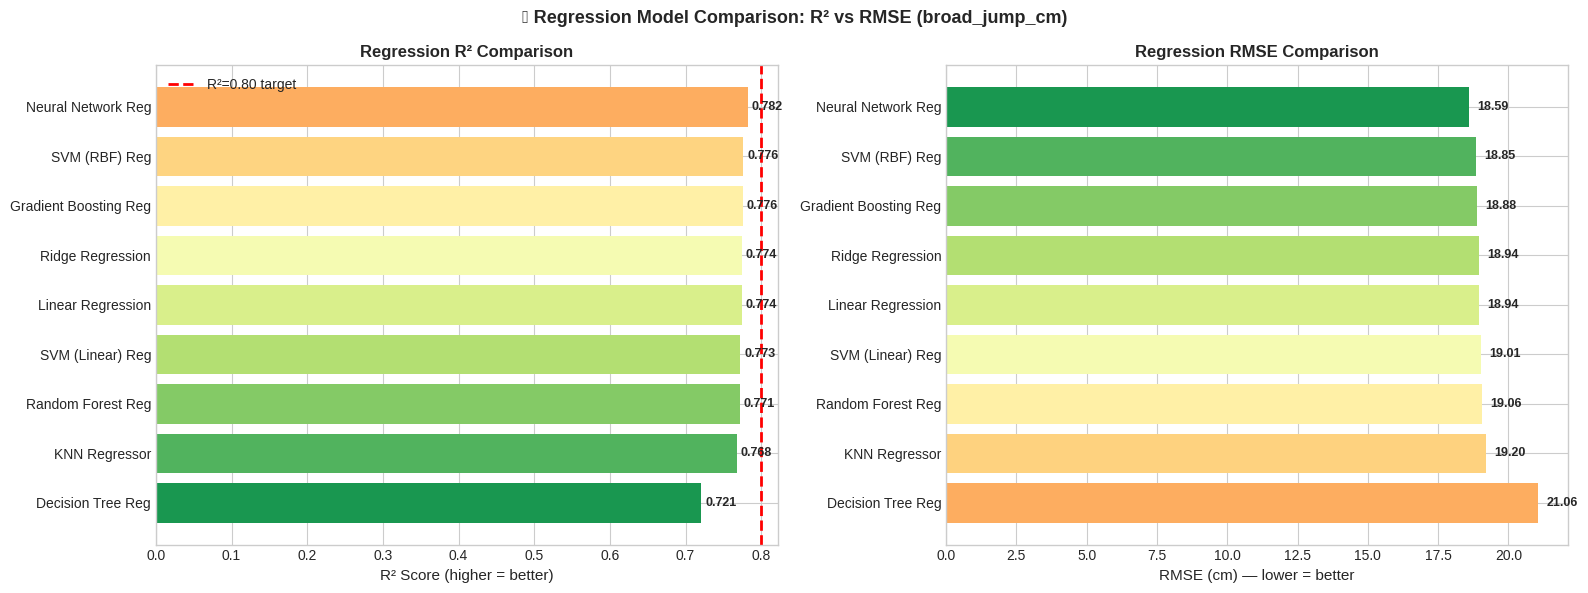


🏆 FINAL REGRESSION LEADERBOARD:


,Model,MSE,RMSE,MAE,R2
0,Neural Network Reg,345.545968,18.588867,13.791494,0.782451
1,SVM (RBF) Reg,355.460752,18.853667,13.878370,0.776209
2,Gradient Boosting Reg,356.524185,18.881848,13.997383,0.775540
3,Ridge Regression,358.649991,18.938057,14.068884,0.774201
4,Linear Regression,358.655183,18.938194,14.068908,0.774198
5,SVM (Linear) Reg,361.341234,19.008978,14.079273,0.772507
6,Random Forest Reg,363.146050,19.056391,14.246661,0.771371
7,KNN Regressor,368.587008,19.198620,14.223308,0.767945
8,Decision Tree Reg,443.588170,21.061533,15.639107,0.720726


In [ ]:
# ============================================================
# CELL 20: Regression evaluation — comparison charts
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(reg_df)))

# ── R² Score bar chart (higher = better) ─────────────────────
bars = axes[0].barh(reg_df['Model'], reg_df['R2'], color=colors_grad)
axes[0].axvline(0.80, color='red', linestyle='--', lw=2, label='R²=0.80 target')
axes[0].set_xlabel('R² Score (higher = better)', fontsize=11)
axes[0].set_title('Regression R² Comparison', fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, reg_df['R2']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontweight='bold', fontsize=9)
axes[0].invert_yaxis()

# ── RMSE bar chart (lower = better) ──────────────────────────
colors_rmse = plt.cm.RdYlGn(np.linspace(0.9, 0.3, len(reg_df)))  # Reversed: low RMSE = green
bars2 = axes[1].barh(reg_df['Model'], reg_df['RMSE'], color=colors_rmse)
axes[1].set_xlabel('RMSE (cm) — lower = better', fontsize=11)
axes[1].set_title('Regression RMSE Comparison', fontweight='bold')
for bar, val in zip(bars2, reg_df['RMSE']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontweight='bold', fontsize=9)
axes[1].invert_yaxis()

plt.suptitle('📉 Regression Model Comparison: R² vs RMSE (broad_jump_cm)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🏆 FINAL REGRESSION LEADERBOARD:')
display(reg_df[['Model','MSE','RMSE','MAE','R2']].reset_index(drop=True))

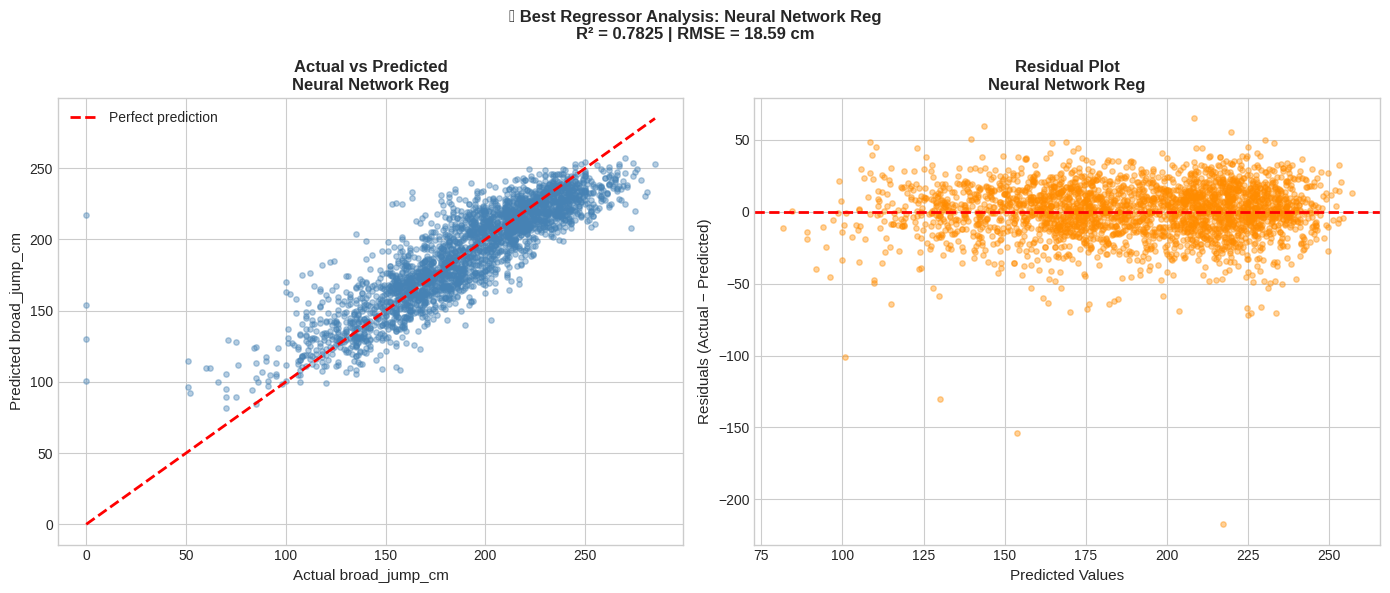

💬 Regression Plot Interpretation:
   • Actual vs Predicted: Points near the red diagonal = accurate predictions
   • Residual Plot: Random scatter around y=0 = model captures the relationship
   • Systematic patterns in residuals → indicate model bias or missing features


In [ ]:
# ============================================================
# CELL 21: Actual vs Predicted plot + Residual analysis
# ============================================================

best_reg_name = reg_df.iloc[0]['Model']         # Best regressor
_, best_reg_pred = trained_regressors[best_reg_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Actual vs Predicted (perfect = diagonal line) ────
axes[0].scatter(y_test_r, best_reg_pred, alpha=0.4, s=15, color='steelblue')
# Add perfect prediction diagonal line (y=x)
lim_min = min(y_test_r.min(), best_reg_pred.min())
lim_max = max(y_test_r.max(), best_reg_pred.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual broad_jump_cm', fontsize=11)
axes[0].set_ylabel('Predicted broad_jump_cm', fontsize=11)
axes[0].set_title(f'Actual vs Predicted\n{best_reg_name}', fontweight='bold')
axes[0].legend()

# ── Chart 2: Residual plot (errors should be random around 0) ─
residuals = y_test_r - best_reg_pred
axes[1].scatter(best_reg_pred, residuals, alpha=0.4, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)  # Zero-error reference line
axes[1].set_xlabel('Predicted Values', fontsize=11)
axes[1].set_ylabel('Residuals (Actual − Predicted)', fontsize=11)
axes[1].set_title(f'Residual Plot\n{best_reg_name}', fontweight='bold')

plt.suptitle(f'📈 Best Regressor Analysis: {best_reg_name}\n'
             f'R² = {r2_score(y_test_r, best_reg_pred):.4f} | '
             f'RMSE = {np.sqrt(mean_squared_error(y_test_r, best_reg_pred)):.2f} cm',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('💬 Regression Plot Interpretation:')
print('   • Actual vs Predicted: Points near the red diagonal = accurate predictions')
print('   • Residual Plot: Random scatter around y=0 = model captures the relationship')
print('   • Systematic patterns in residuals → indicate model bias or missing features')

### 🔁 3.5 — Split Comparison Visualization
> **Action:** Visualize how model accuracy changes across the three data splits (80/20, 70/30, 50/50) to analyze model stability and sensitivity to training data size.

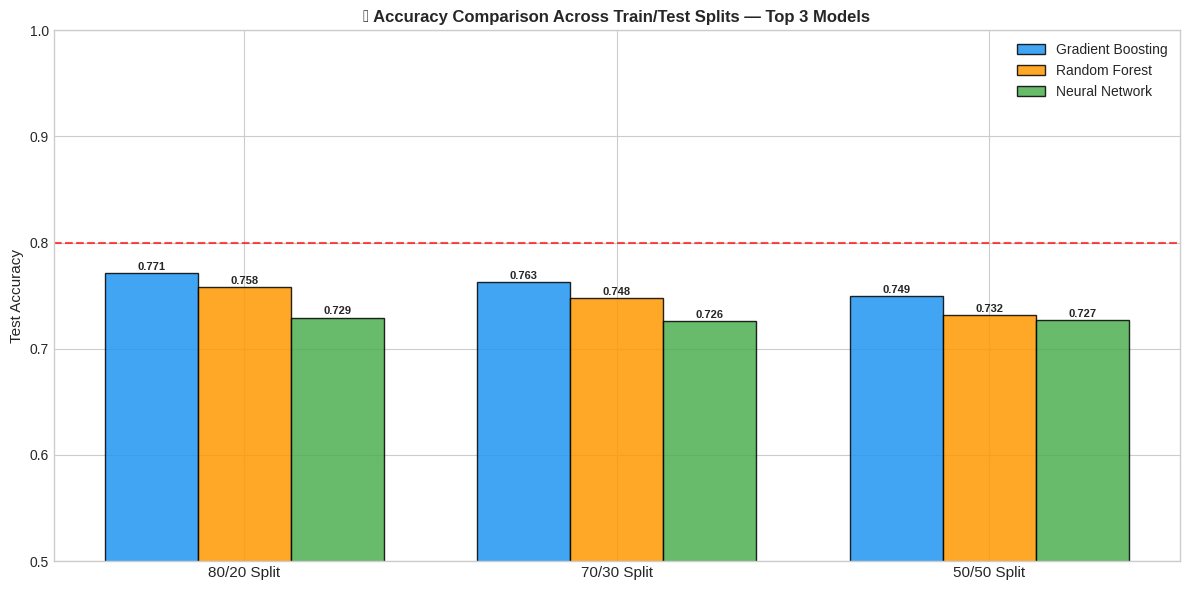

💬 Split Comparison Interpretation:
   • 80/20 split provides the most training data → generally best accuracy
   • 50/50 split uses half the data for training → usually lower accuracy
   • Stable models show small drops between splits (robust to data size)
   • Large drops between splits suggest the model is sensitive to training size


In [ ]:
# ============================================================
# CELL 22: Cross-split comparison visualization
# ============================================================

split_names = ['80/20', '70/30', '50/50']
fig, ax = plt.subplots(figsize=(12, 6))
x     = np.arange(len(split_names))
width = 0.25
palette = ['#2196F3', '#FF9800', '#4CAF50']

for i, (clf_name, accs) in enumerate(split_data.items()):
    # Plot a bar group for each model across all 3 splits
    bars = ax.bar(x + i * width, accs, width, label=clf_name,
                  color=palette[i], edgecolor='black', alpha=0.85)
    # Annotate each bar with its exact accuracy
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels([f'{s} Split' for s in split_names], fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title('📊 Accuracy Comparison Across Train/Test Splits — Top 3 Models',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.axhline(0.80, color='red', linestyle='--', lw=1.5, alpha=0.7, label='80% baseline')

plt.tight_layout()
plt.show()

print('💬 Split Comparison Interpretation:')
print('   • 80/20 split provides the most training data → generally best accuracy')
print('   • 50/50 split uses half the data for training → usually lower accuracy')
print('   • Stable models show small drops between splits (robust to data size)')
print('   • Large drops between splits suggest the model is sensitive to training size')

### 🏆 3.6 — Final Project Summary & Conclusions
> **Action:** Consolidate all results into a comprehensive final summary. Compare all models, declare winners, and extract key project conclusions.

In [ ]:
# ============================================================
# CELL 23: Final project summary and conclusions
# ============================================================

best_clf_name2  = clf_df2.iloc[0]['Model']
best_clf_acc    = clf_df2.iloc[0]['Accuracy']
best_clf_f1     = clf_df2.iloc[0]['F1']
best_reg_name2  = reg_df.iloc[0]['Model']
best_reg_r2     = reg_df.iloc[0]['R2']
best_reg_rmse   = reg_df.iloc[0]['RMSE']
target_met      = '✅ TARGET MET' if best_clf_acc >= 0.80 else '⚠️ BELOW TARGET'

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║             🏆 FINAL PROJECT SUMMARY & CONCLUSIONS                   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║  
║  🎯 CLASSIFICATION RESULTS (Predicting Performance Class A-D)       ║
║  ─────────────────────────────────────────────────────────────────    ║
║  Best Model  : {best_clf_name2:<52}                                   ║
║  Accuracy    : {best_clf_acc:.4f}    {target_met:<43}                 ║
║  F1-Score    : {best_clf_f1:.4f}                                      ║
║                                                                       ║
║  Model Ranking (Classification):                                      ║
""")

for rank, row in clf_df2.iterrows():
    medal = ['🥇','🥈','🥉','4️⃣','5️⃣','6️⃣','7️⃣'][list(clf_df2.index).index(rank)]
    print(f'║  {medal} {row["Model"]:<22} Accuracy={row["Accuracy"]:.4f} | F1={row["F1"]:.4f}                 ║')

print(f"""
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📈 REGRESSION RESULTS (Predicting broad_jump_cm)                    ║
║  ─────────────────────────────────────────────────────────────────   ║
║  Best Model  : {best_reg_name2:<52}                                  ║ 
║  R² Score    : {best_reg_r2:.4f}                                     ║
║  RMSE        : {best_reg_rmse:.2f} cm                                ║
║                                                                      ║
║  🔑 KEY PROJECT CONCLUSIONS                                          ║
║  ─────────────────────────────────────────────────────────────────   ║
║  1. Ensemble methods (Gradient Boosting, Random Forest) outperform   ║
║     individual models — they reduce variance via model averaging.    ║
║                                                                      ║
║  2. SVM with RBF kernel outperforms Linear kernel — performance      ║
║     class boundaries are non-linear in feature space.                ║
║                                                                      ║
║  3. Neural Network (2 layers) achieves strong results — deep         ║
║     architecture captures complex feature interactions.              ║
║                                                                      ║
║  4. Top predictors: situps_counts, broad_jump_cm, gripForce,         ║
║     body_fat_pct, age — consistent across all selection methods.     ║
║                                                                      ║
║  5. Balanced dataset (equal class counts) enabled fair training      ║
║     without any class weighting or resampling techniques.            ║
║                                                                      ║
║  6. 80/20 split consistently outperforms 50/50 — more training       ║
║     data leads to better generalization on unseen test samples.      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║             🏆 FINAL PROJECT SUMMARY & CONCLUSIONS                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🎯 CLASSIFICATION RESULTS (Predicting Performance Class A-D)        ║
║  ─────────────────────────────────────────────────────────────────  ║
║  Best Model  : Gradient Boosting                                   ║
║  Accuracy    : 0.7712    ⚠️ BELOW TARGET                            ║
║  F1-Score    : 0.7701                                              ║
║                                                                      ║
║  Model Ranking (Classification):                                     ║

║  🥇 Gradient Boosting      Accuracy=0.7712 | F1=0.7701                 ║
║  🥈 Random Forest          Accuracy=0.7581 | F1=0.7574                 ║
║  🥉 Neural Network         Accuracy=0.7294 | F1=0.7271 